# 🎯 FedBCa Binary Classification - Google Colab

**Radiomics Features (Boruta Selected) - Ready to Train**

## 📋 Overview
Binary classification menggunakan **selected features** dari Boruta feature selection.


### Models
1. XGBoost
2. SVM
3. Neural Network (MLP)

---

## 1️⃣ Setup Environment

Install required packages (Colab).

In [ ]:
%%time
import sys
print(f"Python version: {sys.version}")
print(f"✓ Google Colab environment ready!")

# Install required packages
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn openpyxl
print("\n✓ All packages installed successfully!")

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
✓ Google Colab environment ready!

✓ All packages installed successfully!
CPU times: user 2.4 s, sys: 918 ms, total: 3.31 s
Wall time: 16.1 s


## 2️⃣ Import Libraries

Import all ML and visualization libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("✓ All libraries imported successfully!")
print(f"   Random state: {RANDOM_STATE}")
print("   Train/test split: PREDEFINED CSV FILES (no re-splitting)")
print("   Task: Binary Classification (0/1)")


✓ All libraries imported successfully!
   Random state: 42
   Train/test split: PREDEFINED CSV FILES (no re-splitting)
   Task: Binary Classification (0/1)


## 3️⃣ Upload File

Upload selected features CSV (sudah include labels).

In [ ]:
print("📂 Upload 2 CSV files:")
print("   1. TRAIN selected-features CSV (171 patients)")
print("   2. TEST selected-features CSV (44 patients)")
print()
print("Contoh:")
print("   train_selected_top30_harmonized.csv")
print("   test_selected_top30_harmonized.csv")
print()

uploaded = files.upload()

train_file = None
test_file = None

for filename in uploaded.keys():
    if not filename.lower().endswith(".csv"):
        continue

    name = filename.lower()

    if "train" in name:
        train_file = filename
        print(f"✓ TRAIN file detected: {filename}")

    if "test" in name:
        test_file = filename
        print(f"✓ TEST file detected: {filename}")

if train_file is None:
    raise FileNotFoundError(
        "❌ TRAIN CSV tidak ditemukan. "
        "Nama file harus mengandung 'train'."
    )

if test_file is None:
    raise FileNotFoundError(
        "❌ TEST CSV tidak ditemukan. "
        "Nama file harus mengandung 'test'."
    )

print("\n✓ TRAIN and TEST files uploaded successfully!")


📂 Upload 2 CSV files:
   1. TRAIN selected-features CSV (171 patients)
   2. TEST selected-features CSV (44 patients)

Contoh:
   train_selected_top30_harmonized.csv
   test_selected_top30_harmonized.csv



Saving test_selected_stable_top30_harmonized.csv to test_selected_stable_top30_harmonized.csv
Saving train_selected_stable_top30_harmonized.csv to train_selected_stable_top30_harmonized.csv
✓ TEST file detected: test_selected_stable_top30_harmonized.csv
✓ TRAIN file detected: train_selected_stable_top30_harmonized.csv

✓ TRAIN and TEST files uploaded successfully!


## 4️⃣ Load Data

Load selected features + labels dari CSV.

In [ ]:
print("="*70)
print("LOADING PRE-SPLIT TRAIN / TEST DATA")
print("="*70)

print(f"Loading TRAIN: {train_file}")
train_df = pd.read_csv(train_file)

print(f"Loading TEST : {test_file}")
test_df = pd.read_csv(test_file)

print(f"\n✓ Train shape: {train_df.shape}")
print(f"✓ Test shape : {test_df.shape}")

if 'label' not in train_df.columns or 'label' not in test_df.columns:
    raise ValueError("Both TRAIN and TEST CSV files must contain a 'label' column.")

if 'PatientID' not in train_df.columns or 'PatientID' not in test_df.columns:
    raise ValueError("Both TRAIN and TEST CSV files must contain a 'PatientID' column.")

# ------------------------------------------------------------
# Verify patient-level independence
# ------------------------------------------------------------
train_patients = set(train_df['PatientID'].astype(str))
test_patients = set(test_df['PatientID'].astype(str))

overlap = train_patients.intersection(test_patients)

if overlap:
    raise ValueError(
        "❌ PATIENT LEAKAGE DETECTED: some PatientID values occur in both "
        f"TRAIN and TEST: {sorted(overlap)}"
    )

print(f"\n✓ Patient-level split verified")
print(f"  Train patients: {len(train_patients)}")
print(f"  Test patients : {len(test_patients)}")

# ------------------------------------------------------------
# Determine feature columns from TRAIN and require exact match
# ------------------------------------------------------------
metadata_cols = ['PatientID', 'label', 'Center', 'Split', 'Condition']

selected_features = [
    c for c in train_df.columns
    if c not in metadata_cols
]

missing_in_test = [
    c for c in selected_features
    if c not in test_df.columns
]

extra_in_test = [
    c for c in test_df.columns
    if c not in metadata_cols and c not in selected_features
]

if missing_in_test:
    raise ValueError(
        "❌ TEST is missing features that exist in TRAIN:\n"
        + "\n".join(missing_in_test)
    )

if extra_in_test:
    print("⚠ TEST contains extra non-feature columns; they will be ignored:")
    print(extra_in_test)

print(f"\n✓ Selected features: {len(selected_features)}")
print(f"  First 5: {selected_features[:5]}")

# ------------------------------------------------------------
# Build X/y WITHOUT doing another train_test_split
# ------------------------------------------------------------
X_train = train_df[selected_features].copy()
y_train = train_df['label'].copy()

X_test = test_df[selected_features].copy()
y_test = test_df['label'].copy()

print("\n📊 Label distribution:")
print("TRAIN:")
for label, count in y_train.value_counts().sort_index().items():
    print(f"  Label {label}: {count:3d} ({count/len(y_train)*100:5.1f}%)")

print("TEST:")
for label, count in y_test.value_counts().sort_index().items():
    print(f"  Label {label}: {count:3d} ({count/len(y_test)*100:5.1f}%)")

print("\n" + "="*70)


LOADING PRE-SPLIT TRAIN / TEST DATA
Loading TRAIN: train_selected_stable_top30_harmonized.csv
Loading TEST : test_selected_stable_top30_harmonized.csv

✓ Train shape: (171, 35)
✓ Test shape : (44, 35)

✓ Patient-level split verified
  Train patients: 171
  Test patients : 44

✓ Selected features: 31
  First 5: ['MaskIndex', 'log-sigma-2-0-mm-3D_glrlm_RunEntropy', 'log-sigma-3-0-mm-3D_glrlm_LongRunHighGrayLevelEmphasis', 'log-sigma-3-0-mm-3D_glrlm_RunEntropy', 'log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity']

📊 Label distribution:
TRAIN:
  Label 0: 109 ( 63.7%)
  Label 1:  62 ( 36.3%)
TEST:
  Label 0:  29 ( 65.9%)
  Label 1:  15 ( 34.1%)



CENTER DISTRIBUTION: TRAIN vs TEST

In [ ]:
print("="*70)
print("CENTER DISTRIBUTION: TRAIN vs TEST")
print("="*70)

# ============================================================
# 1. CHECK CENTER COLUMN
# ============================================================

if 'Center' not in train_df.columns or 'Center' not in test_df.columns:
    raise ValueError(
        "❌ Kolom 'Center' harus tersedia pada TRAIN dan TEST "
        "untuk mengevaluasi distribusi antar-center."
    )

# Pastikan Center berupa string
train_df['Center'] = train_df['Center'].astype(str)
test_df['Center'] = test_df['Center'].astype(str)

# ============================================================
# 2. CENTER COUNTS
# ============================================================

train_center_counts = train_df['Center'].value_counts().sort_index()
test_center_counts = test_df['Center'].value_counts().sort_index()

center_table = pd.DataFrame({
    'Train_N': train_center_counts,
    'Test_N': test_center_counts
}).fillna(0).astype(int)

# ============================================================
# 3. CENTER PERCENTAGES
# ============================================================

center_table['Train_%'] = (
    center_table['Train_N'] / len(train_df) * 100
)

center_table['Test_%'] = (
    center_table['Test_N'] / len(test_df) * 100
)

# Difference in percentage points
center_table['Difference_pp'] = (
    center_table['Test_%'] - center_table['Train_%']
)

print("\n📊 CENTER DISTRIBUTION")
print(center_table.round(2).to_string())

# ============================================================
# 4. IDENTIFY DOMINANT CENTER IN TEST
# ============================================================

dominant_center = test_center_counts.idxmax()
dominant_count = test_center_counts.max()
dominant_percentage = dominant_count / len(test_df) * 100

print("\n" + "-"*70)
print("TEST SET CENTER CHECK")
print("-"*70)

print(f"Total TEST patients : {len(test_df)}")
print(f"Number of centers   : {test_df['Center'].nunique()}")

print(
    f"\nDominant TEST center: {dominant_center}"
)
print(
    f"Patients            : {dominant_count}"
)
print(
    f"Percentage          : {dominant_percentage:.2f}%"
)

# ============================================================
# 5. CENTER DISTRIBUTION BY SPLIT
# ============================================================

print("\n" + "-"*70)
print("CENTER × SPLIT")
print("-"*70)

combined_df = pd.concat([
    train_df.assign(Split_Check='Train'),
    test_df.assign(Split_Check='Test')
])

center_split_table = pd.crosstab(
    combined_df['Center'],
    combined_df['Split_Check']
)

print(center_split_table)

# ============================================================
# 6. CENTER × LABEL × SPLIT
# ============================================================

print("\n" + "-"*70)
print("CENTER × LABEL × SPLIT")
print("-"*70)

center_label_table = pd.crosstab(
    [
        combined_df['Center'],
        combined_df['Split_Check']
    ],
    combined_df['label']
)

print(center_label_table)

print("\n" + "="*70)
print("✓ CENTER DISTRIBUTION CHECK COMPLETED")
print("="*70)


# ============================================================
# 7. LEAVE-ONE-CENTER-OUT (LOCO) VALIDATION VERIFICATION
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut

print("\n")
print("="*70)
print("LEAVE-ONE-CENTER-OUT VALIDATION VERIFICATION")
print("="*70)

# ------------------------------------------------------------
# IMPORTANT:
# LOCO is performed ONLY within the 171-patient TRAIN set.
#
# The 44-patient TEST set remains completely untouched.
#
# Each fold:
#   - 3 centers -> training
#   - 1 center  -> validation
# ------------------------------------------------------------

# Verify required variables
required_variables = [
    'X_train',
    'y_train',
    'train_df'
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:
    raise NameError(
        "❌ Variabel berikut tidak ditemukan: "
        + ", ".join(missing_variables)
    )

# ------------------------------------------------------------
# Verify TRAIN / TEST sizes
# ------------------------------------------------------------

if len(train_df) != len(X_train):
    raise ValueError(
        "❌ Jumlah pasien TRAIN tidak sama dengan X_train."
    )

if len(train_df) != len(y_train):
    raise ValueError(
        "❌ Jumlah pasien TRAIN tidak sama dengan y_train."
    )

print("\nTRAIN / TEST STATUS")
print("-"*70)

print(f"TRAIN patients : {len(train_df)}")
print(f"TEST patients  : {len(test_df)}")

print(
    "✓ LOCO validation akan menggunakan TRAIN saja."
)
print(
    "✓ TEST set tidak digunakan dalam LOCO validation."
)

# ------------------------------------------------------------
# Define groups
# ------------------------------------------------------------

groups_train = train_df['Center'].astype(str).reset_index(drop=True)

X_train_loco = X_train.reset_index(drop=True)
y_train_loco = y_train.reset_index(drop=True)

# ------------------------------------------------------------
# Verify alignment
# ------------------------------------------------------------

if not (
    len(groups_train) ==
    len(X_train_loco) ==
    len(y_train_loco)
):
    raise ValueError(
        "❌ TRAIN data, labels, dan Center groups "
        "memiliki jumlah pasien yang berbeda."
    )

print("\n✓ TRAIN alignment verified")
print(f"  X_train : {len(X_train_loco)}")
print(f"  y_train : {len(y_train_loco)}")
print(f"  Center  : {len(groups_train)}")

# ------------------------------------------------------------
# Initialize LOCO
# ------------------------------------------------------------

logo = LeaveOneGroupOut()

unique_centers = sorted(
    groups_train.unique()
)

print("\nTRAIN CENTERS")
print("-"*70)

for center in unique_centers:

    n_center = (
        groups_train == center
    ).sum()

    print(
        f"  {center}: {n_center} patients "
        f"({n_center / len(groups_train) * 100:.2f}%)"
    )

# ------------------------------------------------------------
# Generate and verify LOCO folds
# ------------------------------------------------------------

print("\n" + "-"*70)
print("LOCO FOLD STRUCTURE")
print("-"*70)

loco_folds = []

for fold, (train_idx, val_idx) in enumerate(
    logo.split(
        X_train_loco,
        y_train_loco,
        groups=groups_train
    ),
    start=1
):

    train_centers = sorted(
        groups_train.iloc[train_idx].unique()
    )

    validation_centers = sorted(
        groups_train.iloc[val_idx].unique()
    )

    train_center_set = set(train_centers)
    validation_center_set = set(validation_centers)

    # --------------------------------------------------------
    # Verify exactly one center is held out
    # --------------------------------------------------------

    if len(validation_centers) != 1:
        raise ValueError(
            f"❌ Fold {fold} memiliki "
            f"{len(validation_centers)} validation centers. "
            "Seharusnya tepat 1 center."
        )

    # --------------------------------------------------------
    # Verify no center overlap
    # --------------------------------------------------------

    if train_center_set.intersection(
        validation_center_set
    ):
        raise ValueError(
            f"❌ CENTER LEAKAGE pada LOCO Fold {fold}."
        )

    # --------------------------------------------------------
    # Store fold information
    # --------------------------------------------------------

    validation_center = validation_centers[0]

    loco_folds.append({
        'Fold': fold,
        'Validation_Center': validation_center,
        'Training_Centers': ', '.join(train_centers),
        'Training_N': len(train_idx),
        'Validation_N': len(val_idx)
    })

    print(f"\nFold {fold}")
    print(
        f"  Training centers   : "
        f"{', '.join(train_centers)}"
    )
    print(
        f"  Validation center  : "
        f"{validation_center}"
    )
    print(
        f"  Training patients  : "
        f"{len(train_idx)}"
    )
    print(
        f"  Validation patients: "
        f"{len(val_idx)}"
    )

# ------------------------------------------------------------
# LOCO fold summary table
# ------------------------------------------------------------

loco_summary_df = pd.DataFrame(loco_folds)

print("\n" + "-"*70)
print("LOCO SUMMARY")
print("-"*70)

print(
    loco_summary_df.to_string(index=False)
)

# ------------------------------------------------------------
# Final LOCO verification
# ------------------------------------------------------------

expected_folds = len(unique_centers)

if len(loco_summary_df) != expected_folds:
    raise ValueError(
        f"❌ Jumlah LOCO folds = "
        f"{len(loco_summary_df)}, "
        f"expected = {expected_folds}."
    )

if set(
    loco_summary_df['Validation_Center']
) != set(unique_centers):

    raise ValueError(
        "❌ Tidak semua center digunakan sebagai "
        "validation center tepat satu kali."
    )

print("\n" + "="*70)
print("✓ LOCO VALIDATION STRUCTURE VERIFIED")
print("="*70)

print(
    f"\nNumber of LOCO folds : {len(loco_summary_df)}"
)

print(
    f"Centers evaluated    : "
    f"{', '.join(unique_centers)}"
)

print(
    "\n✓ Each center is used as validation exactly once"
)

print(
    "✓ Training and validation centers do not overlap"
)

print(
    "✓ LOCO uses TRAIN patients only"
)

print(
    "✓ Held-out TEST patients remain untouched"
)

print("="*70)

CENTER DISTRIBUTION: TRAIN vs TEST

📊 CENTER DISTRIBUTION
         Train_N  Test_N  Train_%  Test_%  Difference_pp
Center                                                  
Center1       93      26    54.39   59.09           4.70
Center2       36      11    21.05   25.00           3.95
Center3       15       3     8.77    6.82          -1.95
Center4       27       4    15.79    9.09          -6.70

----------------------------------------------------------------------
TEST SET CENTER CHECK
----------------------------------------------------------------------
Total TEST patients : 44
Number of centers   : 4

Dominant TEST center: Center1
Patients            : 26
Percentage          : 59.09%

----------------------------------------------------------------------
CENTER × SPLIT
----------------------------------------------------------------------
Split_Check  Test  Train
Center                  
Center1        26     93
Center2        11     36
Center3         3     15
Center4         4 

## 5️⃣ Preprocessing

Handle missing values, scale, dan split train/test.

In [ ]:
print("="*70)
print("PREPROCESSING - NO SECOND TRAIN/TEST SPLIT")
print("="*70)

# X_train, X_test, y_train, y_test were already created from the
# pre-defined TRAIN/TEST CSV files in Step 4.
#
# IMPORTANT:
# No train_test_split() is performed here.
#
# Imputation and scaling are NOT fitted here because they must occur
# inside the CV pipeline to prevent fold-to-fold information leakage.

# Replace non-finite values with NaN.
# This operation does not estimate parameters from the data.
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

print(f"✓ Train samples: {len(X_train)}")
print(f"✓ Test samples : {len(X_test)}")
print(f"✓ Features     : {len(selected_features)}")

# Training-only class distribution for XGBoost
unique, counts = np.unique(y_train, return_counts=True)

print("\n📊 Training class distribution:")
for label, count in zip(unique, counts):
    print(f"  Label {label}: {count:3d} ({count/len(y_train)*100:5.1f}%)")

neg_count = counts[unique.tolist().index(0)] if 0 in unique else 0
pos_count = counts[unique.tolist().index(1)] if 1 in unique else 0

scale_pos_weight_val = (
    neg_count / pos_count if pos_count > 0 else 1.0
)

print(
    f"\nCalculated scale_pos_weight from TRAIN only: "
    f"{scale_pos_weight_val:.4f}"
)

print("\n✓ No imputer/scaler fitted yet.")
print("  They will be fitted INSIDE each 5-fold CV training fold.")
print("="*70)


PREPROCESSING - NO SECOND TRAIN/TEST SPLIT
✓ Train samples: 171
✓ Test samples : 44
✓ Features     : 31

📊 Training class distribution:
  Label 0: 109 ( 63.7%)
  Label 1:  62 ( 36.3%)

Calculated scale_pos_weight from TRAIN only: 1.7581

✓ No imputer/scaler fitted yet.
  They will be fitted INSIDE each 5-fold CV training fold.


## 6️⃣ Loco Training

In [ ]:

# ============================================================
# LOCO TRAINING + VALIDATION
# USING EXISTING BORUTA-SELECTED FEATURES
# ============================================================
#
# IMPORTANT:
# - Boruta has already been performed previously.
# - Existing `selected_features` are reused.
# - Boruta is NOT repeated here.
# - TEST (44 patients) remains untouched.
# - Hyperparameter tuning is repeated inside each LOCO fold.
#
# NOTE:
# Because selected_features were obtained before LOCO,
# this LOCO should be interpreted as:
#
#   CENTER-WISE ROBUSTNESS / GENERALIZATION ANALYSIS
#
# rather than fully nested leakage-free feature selection.
# ============================================================


import numpy as np
import pandas as pd

from sklearn.model_selection import (
    LeaveOneGroupOut,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier

from scipy.stats import uniform, randint


print("=" * 70)
print("LOCO TRAINING + VALIDATION")
print("USING EXISTING BORUTA FEATURES")
print("=" * 70)


# ============================================================
# 1. VERIFY REQUIRED VARIABLES
# ============================================================

required_variables = [
    'X_train',
    'y_train',
    'train_df',
    'selected_features',
    'RANDOM_STATE',
    'scale_pos_weight_val'
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise NameError(
        "❌ Variabel berikut tidak ditemukan: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 2. VERIFY SELECTED FEATURES
# ============================================================

if len(selected_features) == 0:

    raise ValueError(
        "❌ selected_features kosong."
    )


missing_features = [
    feature
    for feature in selected_features
    if feature not in X_train.columns
]

if missing_features:

    raise ValueError(
        "❌ Feature hasil Boruta berikut "
        "tidak ditemukan di X_train:\n"
        + ", ".join(missing_features)
    )


print("\nFEATURE SELECTION STATUS")
print("-" * 70)

print(
    f"Original features : "
    f"{X_train.shape[1]}"
)

print(
    f"Boruta features   : "
    f"{len(selected_features)}"
)

print(
    "\n✓ Existing Boruta-selected features "
    "will be reused."
)

print(
    "✓ Boruta will NOT be repeated."
)


# ============================================================
# 3. PREPARE LOCO DATA
# ============================================================

X_loco = (
    X_train[
        selected_features
    ]
    .reset_index(drop=True)
    .copy()
)

y_loco = (
    y_train
    .reset_index(drop=True)
    .copy()
)

groups_loco = (
    train_df['Center']
    .astype(str)
    .reset_index(drop=True)
)


# ============================================================
# 4. ALIGNMENT CHECK
# ============================================================

if not (
    len(X_loco) ==
    len(y_loco) ==
    len(groups_loco)
):

    raise ValueError(
        "❌ X_train, y_train, dan Center "
        "memiliki jumlah pasien berbeda."
    )


print("\nTRAINING DATA")
print("-" * 70)

print(
    f"Patients : {len(X_loco)}"
)

print(
    f"Features : {X_loco.shape[1]}"
)

print(
    f"Centers  : {groups_loco.nunique()}"
)


# ============================================================
# 5. CENTER DISTRIBUTION
# ============================================================

print("\nCENTER DISTRIBUTION")
print("-" * 70)

print(
    groups_loco
    .value_counts()
    .sort_index()
)


# ============================================================
# 6. LOCO SETUP
# ============================================================

logo = LeaveOneGroupOut()

unique_centers = sorted(
    groups_loco.unique()
)

print("\n" + "=" * 70)
print("LOCO CONFIGURATION")
print("=" * 70)

print(
    f"Number of centers : "
    f"{len(unique_centers)}"
)

print(
    f"Number of folds   : "
    f"{len(unique_centers)}"
)

print(
    "Validation rule   : "
    "1 center held out per fold"
)


# ============================================================
# 7. HYPERPARAMETER DISTRIBUTIONS
# ============================================================

# ------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------

xgb_param_dist = {

    'model__n_estimators': randint(
        100,
        800
    ),

    'model__max_depth': randint(
        2,
        6
    ),

    'model__learning_rate': np.logspace(
        -2.5,
        -0.7,
        30
    ),

    'model__subsample': uniform(
        0.65,
        0.35
    ),

    'model__colsample_bytree': uniform(
        0.65,
        0.35
    ),

    'model__min_child_weight': randint(
        1,
        10
    ),

    'model__gamma': uniform(
        0,
        1
    ),

    'model__reg_alpha': np.logspace(
        -4,
        0,
        20
    ),

    'model__reg_lambda': np.logspace(
        0,
        2,
        20
    ),

    'model__scale_pos_weight': [
        scale_pos_weight_val
    ]
}


# ------------------------------------------------------------
# SVM RBF
# ------------------------------------------------------------

svm_param_dist = {

    'model__C': np.logspace(
        -3,
        3,
        100
    ),

    'model__gamma': np.logspace(
        -5,
        0,
        100
    ),

    'model__class_weight': [
        'balanced',
        None
    ],

    'model__kernel': [
        'rbf'
    ]
}


# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

mlp_param_dist = {

    'model__hidden_layer_sizes': [
        (8,),
        (16,),
        (32,),
        (16, 8),
        (32, 16)
    ],

    'model__activation': [
        'relu',
        'tanh'
    ],

    'model__alpha': np.logspace(
        -4,
        0,
        30
    ),

    'model__learning_rate_init': np.logspace(
        -4,
        -1.5,
        20
    ),

    'model__learning_rate': [
        'constant',
        'adaptive'
    ]
}


# ============================================================
# 8. RESULT STORAGE
# ============================================================

loco_results = []

loco_params = []


# ============================================================
# 9. LOCO LOOP
# ============================================================

for fold, (train_idx, val_idx) in enumerate(

    logo.split(
        X_loco,
        y_loco,
        groups=groups_loco
    ),

    start=1
):


    print("\n")
    print("=" * 70)
    print(f"LOCO FOLD {fold}")
    print("=" * 70)


    # ========================================================
    # 9.1 SPLIT FOLD
    # ========================================================

    X_fold_train = (
        X_loco
        .iloc[train_idx]
        .copy()
    )

    y_fold_train = (
        y_loco
        .iloc[train_idx]
        .copy()
    )

    X_fold_val = (
        X_loco
        .iloc[val_idx]
        .copy()
    )

    y_fold_val = (
        y_loco
        .iloc[val_idx]
        .copy()
    )


    train_centers = sorted(
        groups_loco
        .iloc[train_idx]
        .unique()
    )

    validation_centers = sorted(
        groups_loco
        .iloc[val_idx]
        .unique()
    )


    # --------------------------------------------------------
    # Verify exactly one validation center
    # --------------------------------------------------------

    if len(validation_centers) != 1:

        raise ValueError(
            f"❌ Fold {fold}: "
            "validation harus tepat satu center."
        )


    validation_center = (
        validation_centers[0]
    )


    # --------------------------------------------------------
    # Verify no center overlap
    # --------------------------------------------------------

    if set(train_centers).intersection(
        set(validation_centers)
    ):

        raise ValueError(
            f"❌ CENTER LEAKAGE pada LOCO Fold {fold}"
        )


    print(
        f"\nTraining centers   : "
        f"{', '.join(train_centers)}"
    )

    print(
        f"Validation center  : "
        f"{validation_center}"
    )

    print(
        f"Training patients  : "
        f"{len(train_idx)}"
    )

    print(
        f"Validation patients: "
        f"{len(val_idx)}"
    )


    # ========================================================
    # 9.2 INNER CV
    # ========================================================
    #
    # Hyperparameter tuning dilakukan hanya pada
    # LOCO training portion.
    #
    # Validation center TIDAK ikut tuning.
    # ========================================================

    inner_cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=RANDOM_STATE
    )


    # ========================================================
    # 9.3 XGBOOST
    # ========================================================

    print("\n" + "-" * 70)
    print("🌲 XGBOOST")
    print("-" * 70)


    xgb_pipeline = Pipeline([

        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        ),

        (
            'scaler',
            StandardScaler()
        ),

        (
            'model',
            XGBClassifier(

                random_state=RANDOM_STATE,

                eval_metric='logloss',

                n_jobs=1
            )
        )
    ])


    grid_xgb_loco = RandomizedSearchCV(

        estimator=xgb_pipeline,

        param_distributions=xgb_param_dist,

        n_iter=200,

        cv=inner_cv,

        scoring='roc_auc',

        n_jobs=-1,

        verbose=0,

        random_state=RANDOM_STATE,

        refit=True,

        return_train_score=False
    )


    grid_xgb_loco.fit(

        X_fold_train,

        y_fold_train
    )


    xgb_prob = (
        grid_xgb_loco
        .predict_proba(
            X_fold_val
        )[:, 1]
    )


    xgb_pred = (
        xgb_prob >= 0.5
    ).astype(int)


    # ========================================================
    # 9.4 SVM RBF
    # ========================================================

    print("\n" + "-" * 70)
    print("🔄 SVM - RBF")
    print("-" * 70)


    svm_pipeline = Pipeline([

        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        ),

        (
            'scaler',
            StandardScaler()
        ),

        (
            'model',
            SVC(

                random_state=RANDOM_STATE,

                probability=True
            )
        )
    ])


    grid_svm_loco = RandomizedSearchCV(

        estimator=svm_pipeline,

        param_distributions=svm_param_dist,

        n_iter=200,

        cv=inner_cv,

        scoring='roc_auc',

        n_jobs=-1,

        verbose=0,

        random_state=RANDOM_STATE,

        refit=True,

        return_train_score=False
    )


    grid_svm_loco.fit(

        X_fold_train,

        y_fold_train
    )


    svm_prob = (
        grid_svm_loco
        .predict_proba(
            X_fold_val
        )[:, 1]
    )


    svm_pred = (
        svm_prob >= 0.5
    ).astype(int)


    # ========================================================
    # 9.5 MLP
    # ========================================================

    print("\n" + "-" * 70)
    print("🧠 MLP")
    print("-" * 70)


    mlp_pipeline = Pipeline([

        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        ),

        (
            'scaler',
            StandardScaler()
        ),

        (
            'model',
            MLPClassifier(

                random_state=RANDOM_STATE,

                max_iter=2000,

                early_stopping=True,

                validation_fraction=0.15,

                n_iter_no_change=30
            )
        )
    ])


    grid_mlp_loco = RandomizedSearchCV(

        estimator=mlp_pipeline,

        param_distributions=mlp_param_dist,

        n_iter=200,

        cv=inner_cv,

        scoring='roc_auc',

        n_jobs=-1,

        verbose=0,

        random_state=RANDOM_STATE,

        refit=True,

        return_train_score=False
    )


    grid_mlp_loco.fit(

        X_fold_train,

        y_fold_train
    )


    mlp_prob = (
        grid_mlp_loco
        .predict_proba(
            X_fold_val
        )[:, 1]
    )


    mlp_pred = (
        mlp_prob >= 0.5
    ).astype(int)


    # ========================================================
    # 9.6 EVALUATION FUNCTION
    # ========================================================

    def evaluate_model(
        y_true,
        y_pred,
        y_prob
    ):

        tn, fp, fn, tp = (
            confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()
        )


        # ----------------------------------------------------
        # ROC-AUC
        #
        # If validation contains only one class,
        # ROC-AUC cannot be calculated.
        # ----------------------------------------------------

        if len(
            np.unique(y_true)
        ) < 2:

            auc = np.nan

        else:

            auc = roc_auc_score(
                y_true,
                y_prob
            )


        return {

            'Accuracy':
                accuracy_score(
                    y_true,
                    y_pred
                ),

            'Recall':
                recall_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            'Precision':
                precision_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            'F1':
                f1_score(
                    y_true,
                    y_pred,
                    zero_division=0
                ),

            'ROC_AUC':
                auc,

            'TN':
                tn,

            'FP':
                fp,

            'FN':
                fn,

            'TP':
                tp
        }


    # ========================================================
    # 9.7 EVALUATE ALL MODELS
    # ========================================================

    model_outputs = {

        'XGBoost':
            (
                xgb_pred,
                xgb_prob
            ),

        'SVM':
            (
                svm_pred,
                svm_prob
            ),

        'MLP':
            (
                mlp_pred,
                mlp_prob
            )
    }


    for model_name, (
        predictions,
        probabilities
    ) in model_outputs.items():


        metrics = evaluate_model(

            y_fold_val,

            predictions,

            probabilities
        )


        loco_results.append({

            'Fold':
                fold,

            'Validation_Center':
                validation_center,

            'Model':
                model_name,

            'Validation_N':
                len(val_idx),

            'Selected_Features':
                len(selected_features),

            'Accuracy':
                metrics['Accuracy'],

            'Recall':
                metrics['Recall'],

            'Precision':
                metrics['Precision'],

            'F1':
                metrics['F1'],

            'ROC_AUC':
                metrics['ROC_AUC'],

            'TN':
                metrics['TN'],

            'FP':
                metrics['FP'],

            'FN':
                metrics['FN'],

            'TP':
                metrics['TP']
        })


        print(
            f"\n{model_name}"
        )

        print(
            f"  Accuracy : "
            f"{metrics['Accuracy']:.4f}"
        )

        print(
            f"  Recall   : "
            f"{metrics['Recall']:.4f}"
        )

        print(
            f"  Precision: "
            f"{metrics['Precision']:.4f}"
        )

        print(
            f"  F1       : "
            f"{metrics['F1']:.4f}"
        )

        if np.isnan(
            metrics['ROC_AUC']
        ):

            print(
                "  ROC-AUC  : "
                "N/A (single class)"
            )

        else:

            print(
                f"  ROC-AUC  : "
                f"{metrics['ROC_AUC']:.4f}"
            )


    # ========================================================
    # 9.8 STORE BEST PARAMETERS
    # ========================================================

    loco_params.append({

        'Fold':
            fold,

        'Validation_Center':
            validation_center,

        'XGBoost_Best_CV_AUC':
            grid_xgb_loco.best_score_,

        'SVM_Best_CV_AUC':
            grid_svm_loco.best_score_,

        'MLP_Best_CV_AUC':
            grid_mlp_loco.best_score_,

        'XGBoost_Best_Params':
            grid_xgb_loco.best_params_,

        'SVM_Best_Params':
            grid_svm_loco.best_params_,

        'MLP_Best_Params':
            grid_mlp_loco.best_params_
    })


# ============================================================
# 10. RESULTS DATAFRAME
# ============================================================

loco_results_df = pd.DataFrame(
    loco_results
)

loco_params_df = pd.DataFrame(
    loco_params
)


# ============================================================
# 11. DISPLAY ALL LOCO RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("LOCO VALIDATION RESULTS")
print("=" * 70)

print(
    loco_results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 12. SUMMARY BY MODEL
# ============================================================

print("\n")
print("=" * 70)
print("LOCO SUMMARY BY MODEL")
print("=" * 70)


loco_summary = (

    loco_results_df

    .groupby('Model')

    [
        [
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC'
        ]
    ]

    .agg(['mean', 'std'])
)


print(
    loco_summary
    .round(4)
    .to_string()
)


# ============================================================
# 13. CENTER-WISE RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("CENTER-WISE LOCO RESULTS")
print("=" * 70)


center_results = (

    loco_results_df

    .sort_values(
        [
            'Model',
            'Validation_Center'
        ]
    )

    [
        [
            'Fold',
            'Validation_Center',
            'Model',
            'Validation_N',
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC',
            'TN',
            'FP',
            'FN',
            'TP'
        ]
    ]
)


print(
    center_results
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 14. BEST HYPERPARAMETERS PER LOCO FOLD
# ============================================================

print("\n")
print("=" * 70)
print("BEST HYPERPARAMETERS PER LOCO FOLD")
print("=" * 70)


for _, row in loco_params_df.iterrows():

    print(
        f"\nFold {row['Fold']} "
        f"(Validation: "
        f"{row['Validation_Center']})"
    )

    print(
        "\nXGBoost:"
    )

    print(
        row['XGBoost_Best_Params']
    )

    print(
        "\nSVM:"
    )

    print(
        row['SVM_Best_Params']
    )

    print(
        "\nMLP:"
    )

    print(
        row['MLP_Best_Params']
    )


# ============================================================
# 15. FINAL VERIFICATION
# ============================================================

print("\n")
print("=" * 70)
print("LOCO METHODOLOGICAL STATUS")
print("=" * 70)

print(
    "✓ TEST set (44 patients) was not used"
)

print(
    "✓ LOCO performed only on TRAIN set (171 patients)"
)

print(
    "✓ Existing Boruta-selected features were reused"
)

print(
    "✓ Boruta was NOT repeated"
)

print(
    "✓ Each center was held out exactly once"
)

print(
    "✓ Training and validation centers do not overlap"
)

print(
    "✓ Hyperparameter tuning performed "
    "inside each LOCO training fold"
)

print(
    "✓ Imputation fitted inside each CV training fold"
)

print(
    "✓ Scaling fitted inside each CV training fold"
)

print(
    "✓ Validation center was not used "
    "for hyperparameter tuning"
)

print(
    "⚠ Feature selection was performed before LOCO"
)

print(
    "⚠ Therefore LOCO is interpreted as "
    "center-wise robustness/generalization analysis"
)

print("=" * 70)



LOCO TRAINING + VALIDATION
USING EXISTING BORUTA FEATURES

FEATURE SELECTION STATUS
----------------------------------------------------------------------
Original features : 31
Boruta features   : 31

✓ Existing Boruta-selected features will be reused.
✓ Boruta will NOT be repeated.

TRAINING DATA
----------------------------------------------------------------------
Patients : 171
Features : 31
Centers  : 4

CENTER DISTRIBUTION
----------------------------------------------------------------------
Center
Center1    93
Center2    36
Center3    15
Center4    27
Name: count, dtype: int64

LOCO CONFIGURATION
Number of centers : 4
Number of folds   : 4
Validation rule   : 1 center held out per fold


LOCO FOLD 1

Training centers   : Center2, Center3, Center4
Validation center  : Center1
Training patients  : 78
Validation patients: 93

----------------------------------------------------------------------
🌲 XGBOOST
----------------------------------------------------------------------

--

## 7️⃣ Results & Evaluation LOCO

In [ ]:
# ============================================================
# LOCO RESULTS & EVALUATION
# ============================================================
#
# IMPORTANT:
# - Uses results from `loco_results_df`
# - No retraining is performed
# - TEST (44 patients) remains completely untouched
#
# LOCO is interpreted as:
# CENTER-WISE ROBUSTNESS / GENERALIZATION ANALYSIS
#
# Existing Boruta-selected features were reused.
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("FINAL LOCO RESULTS & EVALUATION")
print("=" * 70)


# ============================================================
# 1. VERIFY LOCO RESULTS
# ============================================================

if 'loco_results_df' not in globals():

    raise NameError(
        "❌ loco_results_df tidak ditemukan.\n"
        "Jalankan cell LOCO TRAINING terlebih dahulu."
    )


required_columns = [
    'Fold',
    'Validation_Center',
    'Model',
    'Validation_N',
    'Accuracy',
    'Recall',
    'Precision',
    'F1',
    'ROC_AUC',
    'TN',
    'FP',
    'FN',
    'TP'
]

missing_columns = [
    col
    for col in required_columns
    if col not in loco_results_df.columns
]

if missing_columns:

    raise ValueError(
        "❌ Kolom berikut tidak ditemukan dalam "
        "loco_results_df:\n"
        + ", ".join(missing_columns)
    )


print("\n✓ LOCO result dataframe verified")

print(
    f"Total LOCO evaluations : "
    f"{len(loco_results_df)}"
)

print(
    f"Models                 : "
    f"{loco_results_df['Model'].nunique()}"
)

print(
    f"Validation centers     : "
    f"{loco_results_df['Validation_Center'].nunique()}"
)


# ============================================================
# 2. COMPLETE LOCO RESULT TABLE
# ============================================================

print("\n")
print("=" * 70)
print("1. COMPLETE LOCO RESULTS")
print("=" * 70)

loco_result_table = loco_results_df[
    [
        'Fold',
        'Validation_Center',
        'Model',
        'Validation_N',
        'Accuracy',
        'Recall',
        'Precision',
        'F1',
        'ROC_AUC',
        'TN',
        'FP',
        'FN',
        'TP'
    ]
].copy()


print(
    loco_result_table
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 3. LOCO RESULTS BY CENTER
# ============================================================

print("\n")
print("=" * 70)
print("2. CENTER-WISE LOCO PERFORMANCE")
print("=" * 70)

center_performance = loco_results_df[
    [
        'Validation_Center',
        'Model',
        'Validation_N',
        'Accuracy',
        'Recall',
        'Precision',
        'F1',
        'ROC_AUC'
    ]
].copy()

center_performance = center_performance.sort_values(
    [
        'Model',
        'Validation_Center'
    ]
)

print(
    center_performance
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 4. LOCO CONFUSION MATRIX SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("3. LOCO CONFUSION MATRIX")
print("=" * 70)

confusion_summary = loco_results_df[
    [
        'Validation_Center',
        'Model',
        'TN',
        'FP',
        'FN',
        'TP'
    ]
].copy()

confusion_summary = confusion_summary.sort_values(
    [
        'Model',
        'Validation_Center'
    ]
)

print(
    confusion_summary
    .to_string(index=False)
)


# ============================================================
# 5. MEAN ± SD ACROSS CENTERS
# ============================================================
#
# Each center contributes one validation result.
#
# Mean = average performance across centers
# SD   = variability of performance across centers
#
# This is useful for evaluating robustness.
# ============================================================

print("\n")
print("=" * 70)
print("4. LOCO PERFORMANCE: MEAN ± SD ACROSS CENTERS")
print("=" * 70)


metrics = [
    'Accuracy',
    'Recall',
    'Precision',
    'F1',
    'ROC_AUC'
]


loco_mean_sd = (
    loco_results_df
    .groupby('Model')[metrics]
    .agg(['mean', 'std'])
)


print(
    loco_mean_sd
    .round(4)
    .to_string()
)


# ============================================================
# 6. CREATE CLEAN SUMMARY TABLE
# ============================================================

summary_rows = []

for model in sorted(
    loco_results_df['Model'].unique()
):

    model_df = loco_results_df[
        loco_results_df['Model'] == model
    ]

    row = {
        'Model': model
    }

    for metric in metrics:

        mean_value = (
            model_df[metric]
            .mean()
        )

        sd_value = (
            model_df[metric]
            .std()
        )

        row[
            f'{metric}_Mean'
        ] = mean_value

        row[
            f'{metric}_SD'
        ] = sd_value

    summary_rows.append(row)


loco_summary_clean = pd.DataFrame(
    summary_rows
)


print("\n")
print("=" * 70)
print("5. CLEAN LOCO SUMMARY")
print("=" * 70)

print(
    loco_summary_clean
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 7. FORMATTED MEAN ± SD TABLE
# ============================================================

formatted_summary = pd.DataFrame()

formatted_summary['Model'] = (
    loco_summary_clean['Model']
)


for metric in metrics:

    formatted_summary[metric] = [

        f"{mean:.3f} ± {sd:.3f}"

        for mean, sd in zip(

            loco_summary_clean[
                f'{metric}_Mean'
            ],

            loco_summary_clean[
                f'{metric}_SD'
            ]
        )
    ]


print("\n")
print("=" * 70)
print("6. LOCO SUMMARY — MEAN ± SD")
print("=" * 70)

display(
    formatted_summary
)


# ============================================================
# 8. MINIMUM AND MAXIMUM PERFORMANCE ACROSS CENTERS
# ============================================================
#
# This shows whether performance is highly dependent
# on a particular center.
# ============================================================

print("\n")
print("=" * 70)
print("7. LOCO PERFORMANCE RANGE ACROSS CENTERS")
print("=" * 70)


range_rows = []


for model in sorted(
    loco_results_df['Model'].unique()
):

    model_df = loco_results_df[
        loco_results_df['Model'] == model
    ]

    row = {
        'Model': model
    }

    for metric in metrics:

        row[
            f'{metric}_Min'
        ] = model_df[metric].min()

        row[
            f'{metric}_Max'
        ] = model_df[metric].max()

        row[
            f'{metric}_Range'
        ] = (
            model_df[metric].max()
            -
            model_df[metric].min()
        )

    range_rows.append(row)


loco_range_df = pd.DataFrame(
    range_rows
)


print(
    loco_range_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. IDENTIFY BEST / WORST CENTER FOR EACH MODEL
# ============================================================

print("\n")
print("=" * 70)
print("8. BEST AND WORST VALIDATION CENTER")
print("=" * 70)


for model in sorted(
    loco_results_df['Model'].unique()
):

    model_df = loco_results_df[
        loco_results_df['Model'] == model
    ]

    print("\n" + "-" * 70)
    print(model)
    print("-" * 70)


    for metric in [
        'Accuracy',
        'Recall',
        'F1',
        'ROC_AUC'
    ]:

        # Ignore NaN when determining best/worst
        valid_df = model_df[
            model_df[metric].notna()
        ]

        if len(valid_df) == 0:

            print(
                f"{metric}: No valid values"
            )

            continue


        best_idx = valid_df[
            metric
        ].idxmax()

        worst_idx = valid_df[
            metric
        ].idxmin()


        best_center = (
            valid_df
            .loc[
                best_idx,
                'Validation_Center'
            ]
        )

        worst_center = (
            valid_df
            .loc[
                worst_idx,
                'Validation_Center'
            ]
        )


        best_value = (
            valid_df
            .loc[
                best_idx,
                metric
            ]
        )

        worst_value = (
            valid_df
            .loc[
                worst_idx,
                metric
            ]
        )


        print(
            f"{metric:<12} | "
            f"Best: {best_center} "
            f"({best_value:.4f}) | "
            f"Worst: {worst_center} "
            f"({worst_value:.4f})"
        )


# ============================================================
# 10. CENTER-SPECIFIC LABEL DISTRIBUTION
# ============================================================
#
# This helps explain unusually high/low performance.
# ============================================================

print("\n")
print("=" * 70)
print("9. VALIDATION CENTER LABEL DISTRIBUTION")
print("=" * 70)


center_label_distribution = pd.crosstab(
    train_df['Center'].astype(str),
    y_train
)


center_label_distribution.columns = [
    f'Label_{col}'
    for col in center_label_distribution.columns
]


print(
    center_label_distribution
    .to_string()
)


# ============================================================
# 11. VERIFY EACH CENTER WAS EVALUATED ONCE
# ============================================================

print("\n")
print("=" * 70)
print("10. LOCO STRUCTURAL VERIFICATION")
print("=" * 70)


expected_centers = set(
    train_df['Center']
    .astype(str)
    .unique()
)

evaluated_centers = set(
    loco_results_df['Validation_Center']
    .astype(str)
    .unique()
)


if expected_centers != evaluated_centers:

    raise ValueError(
        "❌ Tidak semua center digunakan "
        "sebagai validation center."
    )


counts_per_center = (
    loco_results_df
    .groupby(
        [
            'Validation_Center',
            'Model'
        ]
    )
    .size()
)


expected_models = (
    loco_results_df['Model']
    .nunique()
)


if not (
    counts_per_center == 1
).all():

    raise ValueError(
        "❌ Ada center/model yang dievaluasi "
        "lebih dari satu kali atau tidak tepat satu kali."
    )


print(
    "✓ Semua center digunakan sebagai "
    "validation center."
)

print(
    "✓ Setiap center dievaluasi tepat satu kali "
    "untuk setiap model."
)

print(
    "✓ Tidak ada test patient yang digunakan."
)


# ============================================================
# 12. FINAL METHODOLOGICAL INTERPRETATION
# ============================================================

print("\n")
print("=" * 70)
print("11. FINAL LOCO EVALUATION STATUS")
print("=" * 70)

print(
    "✓ LOCO performed on 171 TRAIN patients only"
)

print(
    "✓ 44 TEST patients remained untouched"
)

print(
    "✓ Each center was held out exactly once"
)

print(
    "✓ Hyperparameter tuning was performed "
    "within each LOCO training fold"
)

print(
    "✓ Imputation and scaling were performed "
    "inside the model pipelines"
)

print(
    "✓ Existing Boruta-selected features were reused"
)

print(
    "⚠ Boruta was not repeated within each LOCO fold"
)

print(
    "⚠ Therefore LOCO is interpreted as "
    "center-wise robustness/generalization analysis"
)

print("=" * 70)

FINAL LOCO RESULTS & EVALUATION

✓ LOCO result dataframe verified
Total LOCO evaluations : 12
Models                 : 3
Validation centers     : 4


1. COMPLETE LOCO RESULTS
 Fold Validation_Center   Model  Validation_N  Accuracy  Recall  Precision     F1  ROC_AUC  TN  FP  FN  TP
    1           Center1 XGBoost            93    0.8387  0.7778     0.5600 0.6512   0.8481  64  11   4  14
    1           Center1     SVM            93    0.8495  0.7222     0.5909 0.6500   0.8348  66   9   5  13
    1           Center1     MLP            93    0.8280  0.6667     0.5455 0.6000   0.8407  65  10   6  12
    2           Center2 XGBoost            36    0.7778  0.7500     0.8333 0.7895   0.8406  13   3   5  15
    2           Center2     SVM            36    0.6944  0.7000     0.7368 0.7179   0.8250  11   5   6  14
    2           Center2     MLP            36    0.7222  0.6500     0.8125 0.7222   0.7969  13   3   7  13
    3           Center3 XGBoost            15    0.8667  0.8889     0.8889 0

,Model,Accuracy,Recall,Precision,F1,ROC_AUC
0,MLP,0.763 ± 0.060,0.674 ± 0.075,0.763 ± 0.148,0.710 ± 0.092,0.804 ± 0.047
1,SVM,0.756 ± 0.089,0.733 ± 0.033,0.736 ± 0.135,0.730 ± 0.068,0.781 ± 0.089
2,XGBoost,0.806 ± 0.057,0.771 ± 0.092,0.779 ± 0.148,0.768 ± 0.099,0.843 ± 0.021




7. LOCO PERFORMANCE RANGE ACROSS CENTERS
  Model  Accuracy_Min  Accuracy_Max  Accuracy_Range  Recall_Min  Recall_Max  Recall_Range  Precision_Min  Precision_Max  Precision_Range  F1_Min  F1_Max  F1_Range  ROC_AUC_Min  ROC_AUC_Max  ROC_AUC_Range
    MLP        0.7037        0.8280          0.1243      0.6000      0.7778        0.1778         0.5455         0.8750           0.3295  0.6000  0.8235    0.2235       0.7407       0.8407         0.1000
    SVM        0.6667        0.8495          0.1828      0.7000      0.7778        0.0778         0.5909         0.9167           0.3258  0.6500  0.8148    0.1648       0.6481       0.8348         0.1867
XGBoost        0.7407        0.8667          0.1259      0.6667      0.8889        0.2222         0.5600         0.8889           0.3289  0.6512  0.8889    0.2377       0.8148       0.8667         0.0519


8. BEST AND WORST VALIDATION CENTER

----------------------------------------------------------------------
MLP
---------------------------

## 8️⃣ Visualizations

Visualisasi performa model.

LOCO VISUALIZATION

Models found: ['MLP', 'SVM', 'XGBoost']


CONFUSION MATRICES — AGGREGATED ACROSS LOCO CENTERS


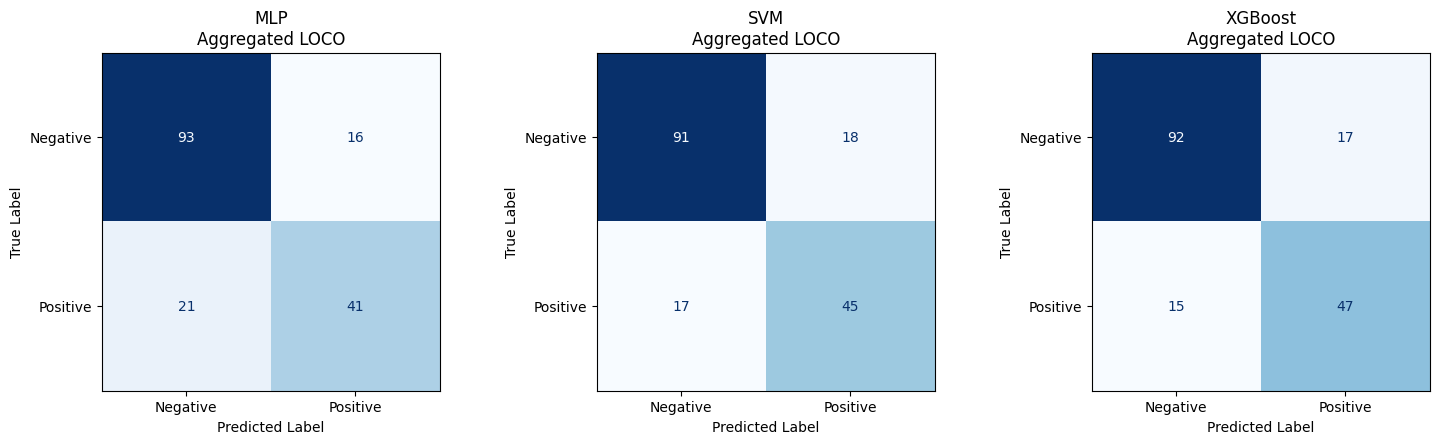


Aggregated confusion matrix values:


,Model,TN,FP,FN,TP
0,MLP,93,16,21,41
1,SVM,91,18,17,45
2,XGBoost,92,17,15,47




⚠ ROC CURVE TIDAK DAPAT DIBUAT

'loco_predictions_df' tidak ditemukan.

ROC-AUC yang ada di loco_results_df tidak cukup untuk menggambar ROC curve.

Yang diperlukan adalah probabilitas prediksi setiap pasien (y_proba) dan label sebenarnya (y_true).

✓ LOCO visualization completed.


In [ ]:
# ============================================================
# LOCO VISUALIZATION
# ROC CURVES + CONFUSION MATRICES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 70)
print("LOCO VISUALIZATION")
print("=" * 70)


# ============================================================
# 1. VERIFY LOCO RESULTS
# ============================================================

if 'loco_results_df' not in globals():
    raise NameError(
        "❌ loco_results_df tidak ditemukan. "
        "Jalankan cell LOCO RESULTS & EVALUATION terlebih dahulu."
    )

models = sorted(loco_results_df['Model'].unique())

print(f"\nModels found: {models}")


# ============================================================
# 2. CONFUSION MATRIX
#    AGGREGATED ACROSS ALL VALIDATION CENTERS
# ============================================================

print("\n")
print("=" * 70)
print("CONFUSION MATRICES — AGGREGATED ACROSS LOCO CENTERS")
print("=" * 70)


fig, axes = plt.subplots(
    1,
    len(models),
    figsize=(5 * len(models), 4.5)
)

# Kalau hanya ada 1 model
if len(models) == 1:
    axes = [axes]


for ax, model in zip(axes, models):

    model_df = loco_results_df[
        loco_results_df['Model'] == model
    ]

    # Aggregate confusion matrix components
    TN = model_df['TN'].sum()
    FP = model_df['FP'].sum()
    FN = model_df['FN'].sum()
    TP = model_df['TP'].sum()

    cm = np.array([
        [TN, FP],
        [FN, TP]
    ])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative', 'Positive']
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d'
    )

    ax.set_title(
        f"{model}\nAggregated LOCO"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")


plt.tight_layout()
plt.show()


# ============================================================
# 3. PRINT AGGREGATED CONFUSION MATRIX VALUES
# ============================================================

print("\nAggregated confusion matrix values:")

cm_summary = []

for model in models:

    model_df = loco_results_df[
        loco_results_df['Model'] == model
    ]

    TN = model_df['TN'].sum()
    FP = model_df['FP'].sum()
    FN = model_df['FN'].sum()
    TP = model_df['TP'].sum()

    cm_summary.append({
        'Model': model,
        'TN': TN,
        'FP': FP,
        'FN': FN,
        'TP': TP
    })


cm_summary_df = pd.DataFrame(cm_summary)

display(cm_summary_df)


# ============================================================
# 4. ROC CURVE
# ============================================================
#
# IMPORTANT:
# ROC curve membutuhkan:
#   - y_true
#   - predicted probability / decision score
#
# Misalnya dataframe:
#
# loco_predictions_df
#
# dengan kolom:
#   Model
#   Validation_Center
#   y_true
#   y_proba
#
# ============================================================


if 'loco_predictions_df' not in globals():

    print("\n")
    print("=" * 70)
    print("⚠ ROC CURVE TIDAK DAPAT DIBUAT")
    print("=" * 70)

    print(
        "\n'loco_predictions_df' tidak ditemukan."
    )

    print(
        "\nROC-AUC yang ada di loco_results_df "
        "tidak cukup untuk menggambar ROC curve."
    )

    print(
        "\nYang diperlukan adalah probabilitas prediksi "
        "setiap pasien (y_proba) dan label sebenarnya (y_true)."
    )

else:

    required_pred_cols = [
        'Model',
        'Validation_Center',
        'y_true',
        'y_proba'
    ]

    missing_pred_cols = [
        col
        for col in required_pred_cols
        if col not in loco_predictions_df.columns
    ]

    if missing_pred_cols:

        raise ValueError(
            "❌ loco_predictions_df tidak memiliki kolom: "
            + ", ".join(missing_pred_cols)
        )


    # ========================================================
    # ROC CURVES
    # ========================================================

    plt.figure(figsize=(8, 7))

    for model in models:

        model_pred = loco_predictions_df[
            loco_predictions_df['Model'] == model
        ].copy()

        y_true = model_pred['y_true'].values
        y_proba = model_pred['y_proba'].values

        fpr, tpr, thresholds = roc_curve(
            y_true,
            y_proba
        )

        roc_auc_value = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model} (AUC = {roc_auc_value:.3f})"
        )


    # Random classifier
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=1.5,
        label='Random classifier (AUC = 0.500)'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(
        "LOCO ROC Curves — All Validation Centers"
    )

    plt.legend(
        loc='lower right'
    )

    plt.grid(
        alpha=0.3
    )

    plt.xlim([0, 1])
    plt.ylim([0, 1.05])

    plt.tight_layout()
    plt.show()


print("\n✓ LOCO visualization completed.")

## 9️⃣ Loco Stacking


In [ ]:
# ============================================================
# LOCO STACKING VALIDATION
# ============================================================
#
# IMPORTANT METHODOLOGICAL NOTE
# ------------------------------------------------------------
# 1. LOCO is performed ONLY on the 171 TRAIN patients.
# 2. The 44-patient TEST set remains completely untouched.
# 3. Existing Boruta-selected features are reused.
# 4. Boruta is NOT repeated inside each LOCO fold.
# 5. Therefore, this analysis represents CENTER-WISE
#    ROBUSTNESS / GENERALIZATION analysis rather than
#    fully nested LOCO feature selection.
#
# Each LOCO fold:
#
#   3 centers -> stacking training
#   1 center  -> stacking validation
#
# Meta learner:
#   Logistic Regression
#
# Base learners:
#   XGBoost
#   SVM
#   MLP
#
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd
import numpy as np


print("=" * 80)
print("LOCO STACKING VALIDATION")
print("=" * 80)


# ============================================================
# 1. VERIFY REQUIRED VARIABLES
# ============================================================

required_variables = [
    'X_train',
    'y_train',
    'train_df',
    'grid_xgb_loco',
    'grid_svm_loco',
    'grid_mlp_loco'
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:
    raise NameError(
        "❌ Variabel berikut tidak ditemukan: "
        + ", ".join(missing_variables)
    )


# ============================================================
# 2. PREPARE LOCO DATA
# ============================================================

X_loco = X_train.reset_index(drop=True)
y_loco = y_train.reset_index(drop=True)

groups_loco = (
    train_df['Center']
    .astype(str)
    .reset_index(drop=True)
)


# ============================================================
# 3. ALIGNMENT CHECK
# ============================================================

if not (
    len(X_loco) ==
    len(y_loco) ==
    len(groups_loco)
):
    raise ValueError(
        "❌ X_train, y_train, dan Center "
        "memiliki jumlah pasien berbeda."
    )


print("\nLOCO DATA")
print("-" * 80)

print(f"Training patients : {len(X_loco)}")
print(f"Centers           : {groups_loco.nunique()}")

print("\nCenter distribution:")

print(
    groups_loco
    .value_counts()
    .sort_index()
)


# ============================================================
# 4. DEFINE BASE MODELS
# ============================================================
#
# IMPORTANT:
# Use the BEST ESTIMATORS obtained from RandomizedSearchCV.
#
# These estimators already contain:
#   - Imputer
#   - StandardScaler
#   - optimized model parameters
#
# They are cloned automatically by StackingClassifier.
#
# ============================================================

xgb_base = grid_xgb_loco.best_estimator_

svm_base = grid_svm_loco.best_estimator_

mlp_base = grid_mlp_loco.best_estimator_


# ============================================================
# 5. STACKING CONFIGURATIONS
# ============================================================

stacking_configs = {

    'XGB+SVM+MLP': [
        ('xgboost', xgb_base),
        ('svm', svm_base),
        ('neural_net', mlp_base)
    ],

    'XGB+SVM': [
        ('xgboost', xgb_base),
        ('svm', svm_base)
    ],

    'SVM+MLP': [
        ('svm', svm_base),
        ('neural_net', mlp_base)
    ],

    'XGB+MLP': [
        ('xgboost', xgb_base),
        ('neural_net', mlp_base)
    ]
}


# ============================================================
# 6. LOCO INITIALIZATION
# ============================================================

logo = LeaveOneGroupOut()

loco_stacking_results = []


# ============================================================
# 7. RUN LOCO
# ============================================================

print("\n" + "=" * 80)
print("RUNNING LOCO STACKING")
print("=" * 80)


for fold, (train_idx, val_idx) in enumerate(
    logo.split(
        X_loco,
        y_loco,
        groups=groups_loco
    ),
    start=1
):

    # --------------------------------------------------------
    # Identify centers
    # --------------------------------------------------------

    training_centers = sorted(
        groups_loco.iloc[train_idx].unique()
    )

    validation_centers = sorted(
        groups_loco.iloc[val_idx].unique()
    )

    if len(validation_centers) != 1:
        raise ValueError(
            f"❌ Fold {fold}: validation harus "
            f"tepat 1 center."
        )

    validation_center = validation_centers[0]


    # --------------------------------------------------------
    # Split data
    # --------------------------------------------------------

    X_fold_train = X_loco.iloc[train_idx]
    y_fold_train = y_loco.iloc[train_idx]

    X_fold_val = X_loco.iloc[val_idx]
    y_fold_val = y_loco.iloc[val_idx]


    # --------------------------------------------------------
    # Print fold information
    # --------------------------------------------------------

    print("\n" + "-" * 80)
    print(f"LOCO FOLD {fold}")
    print("-" * 80)

    print(
        f"Training centers   : "
        f"{', '.join(training_centers)}"
    )

    print(
        f"Validation center  : "
        f"{validation_center}"
    )

    print(
        f"Training patients  : "
        f"{len(train_idx)}"
    )

    print(
        f"Validation patients: "
        f"{len(val_idx)}"
    )


    # ========================================================
    # TRAIN EACH STACKING CONFIGURATION
    # ========================================================

    for stacking_name, estimators in stacking_configs.items():

        print(
            f"\n  → Training stacking: "
            f"{stacking_name}"
        )


        # ----------------------------------------------------
        # Meta learner
        # ----------------------------------------------------

        meta_learner = LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            solver='lbfgs'
        )


        # ----------------------------------------------------
        # Stacking classifier
        # ----------------------------------------------------
        #
        # cv=5 is used INSIDE the training portion of each
        # LOCO fold to generate out-of-fold predictions for
        # the Logistic Regression meta learner.
        #
        # Validation center is NOT involved in this CV.
        #
        # ----------------------------------------------------

        stacking_model = StackingClassifier(
            estimators=estimators,

            final_estimator=meta_learner,

            cv=5,

            stack_method='predict_proba',

            n_jobs=-1
        )


        # ----------------------------------------------------
        # Fit only on LOCO training centers
        # ----------------------------------------------------

        stacking_model.fit(
            X_fold_train,
            y_fold_train
        )


        # ----------------------------------------------------
        # Predict validation center
        # ----------------------------------------------------

        y_pred = stacking_model.predict(
            X_fold_val
        )

        y_proba = stacking_model.predict_proba(
            X_fold_val
        )[:, 1]


        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_fold_val,
            y_pred,
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_fold_val,
            y_pred
        )

        precision = precision_score(
            y_fold_val,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_fold_val,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_fold_val,
            y_pred,
            zero_division=0
        )

        # ROC-AUC requires both classes in validation set
        if len(np.unique(y_fold_val)) == 2:

            roc_auc = roc_auc_score(
                y_fold_val,
                y_proba
            )

        else:

            roc_auc = np.nan


        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        loco_stacking_results.append({

            'Fold': fold,

            'Validation_Center':
                validation_center,

            'Model':
                stacking_name,

            'Validation_N':
                len(val_idx),

            'Accuracy':
                accuracy,

            'Recall':
                recall,

            'Precision':
                precision,

            'F1':
                f1,

            'ROC_AUC':
                roc_auc,

            'TN':
                tn,

            'FP':
                fp,

            'FN':
                fn,

            'TP':
                tp
        })


        print(
            f"     Accuracy : {accuracy:.4f}"
        )

        print(
            f"     Recall   : {recall:.4f}"
        )

        print(
            f"     F1       : {f1:.4f}"
        )

        print(
            f"     ROC-AUC  : {roc_auc:.4f}"
        )


# ============================================================
# 8. CREATE RESULT DATAFRAME
# ============================================================

loco_stacking_df = pd.DataFrame(
    loco_stacking_results
)


# ============================================================
# 9. STRUCTURAL VERIFICATION
# ============================================================

print("\n" + "=" * 80)
print("LOCO STACKING STRUCTURAL VERIFICATION")
print("=" * 80)

expected_evaluations = (
    groups_loco.nunique()
    *
    len(stacking_configs)
)

actual_evaluations = len(
    loco_stacking_df
)

print(
    f"\nExpected evaluations : "
    f"{expected_evaluations}"
)

print(
    f"Actual evaluations   : "
    f"{actual_evaluations}"
)


if actual_evaluations != expected_evaluations:

    raise ValueError(
        "❌ Jumlah LOCO stacking evaluation "
        "tidak sesuai."
    )


# Every center must appear for every stacking model

for model_name in stacking_configs.keys():

    centers = set(
        loco_stacking_df.loc[
            loco_stacking_df['Model'] == model_name,
            'Validation_Center'
        ]
    )

    expected_centers = set(
        groups_loco.unique()
    )

    if centers != expected_centers:

        raise ValueError(
            f"❌ Tidak semua center dievaluasi "
            f"untuk {model_name}."
        )


print("\n✓ All centers evaluated")
print("✓ Each center held out exactly once")
print("✓ Each stacking configuration evaluated")
print("✓ Validation used only the held-out center")
print("✓ TEST set was not used")


# ============================================================
# 10. COMPLETE LOCO STACKING RESULTS
# ============================================================

print("\n" + "=" * 80)
print("COMPLETE LOCO STACKING RESULTS")
print("=" * 80)

display(
    loco_stacking_df[
        [
            'Fold',
            'Validation_Center',
            'Model',
            'Validation_N',
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC',
            'TN',
            'FP',
            'FN',
            'TP'
        ]
    ].round(4)
)


# ============================================================
# 11. CENTER-WISE PERFORMANCE
# ============================================================

print("\n" + "=" * 80)
print("CENTER-WISE STACKING PERFORMANCE")
print("=" * 80)

center_wise_stacking = (
    loco_stacking_df[
        [
            'Validation_Center',
            'Model',
            'Validation_N',
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC'
        ]
    ]
    .sort_values(
        ['Validation_Center', 'Model']
    )
)

display(
    center_wise_stacking.round(4)
)


# ============================================================
# 12. CONFUSION MATRIX SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("LOCO STACKING CONFUSION MATRIX SUMMARY")
print("=" * 80)

stacking_confusion_summary = (
    loco_stacking_df[
        [
            'Validation_Center',
            'Model',
            'TN',
            'FP',
            'FN',
            'TP'
        ]
    ]
    .sort_values(
        ['Model', 'Validation_Center']
    )
)

display(
    stacking_confusion_summary
)


# ============================================================
# 13. MEAN ± SD ACROSS CENTERS
# ============================================================

print("\n" + "=" * 80)
print("LOCO STACKING PERFORMANCE: MEAN ± SD")
print("=" * 80)


stacking_mean_sd = (
    loco_stacking_df
    .groupby('Model')
    [
        [
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC'
        ]
    ]
    .agg(['mean', 'std'])
)


display(
    stacking_mean_sd.round(4)
)


# ============================================================
# 14. CLEAN SUMMARY TABLE
# ============================================================

stacking_summary = (
    loco_stacking_df
    .groupby('Model')
    [
        [
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC'
        ]
    ]
    .agg(['mean', 'std'])
)


stacking_clean_summary = pd.DataFrame(
    index=stacking_summary.index
)


for metric in [
    'Accuracy',
    'Recall',
    'Precision',
    'F1',
    'ROC_AUC'
]:

    stacking_clean_summary[metric] = (

        stacking_summary[
            (metric, 'mean')
        ].map(
            lambda x: f"{x:.3f}"
        )

        +

        " ± "

        +

        stacking_summary[
            (metric, 'std')
        ].map(
            lambda x: f"{x:.3f}"
        )
    )


print("\n" + "=" * 80)
print("CLEAN LOCO STACKING SUMMARY — MEAN ± SD")
print("=" * 80)

display(
    stacking_clean_summary
)


# ============================================================
# 15. PERFORMANCE RANGE ACROSS CENTERS
# ============================================================

print("\n" + "=" * 80)
print("LOCO STACKING PERFORMANCE RANGE")
print("=" * 80)


stacking_range = (
    loco_stacking_df
    .groupby('Model')
    [
        [
            'Accuracy',
            'Recall',
            'Precision',
            'F1',
            'ROC_AUC'
        ]
    ]
    .agg(['min', 'max'])
)


display(
    stacking_range.round(4)
)


# ============================================================
# 16. BEST AND WORST CENTER
# ============================================================

print("\n" + "=" * 80)
print("BEST AND WORST VALIDATION CENTER")
print("=" * 80)


for model_name in stacking_configs.keys():

    model_df = loco_stacking_df[
        loco_stacking_df['Model']
        == model_name
    ]

    print("\n" + "-" * 70)
    print(model_name)
    print("-" * 70)


    # Accuracy
    best_accuracy_idx = (
        model_df['Accuracy'].idxmax()
    )

    worst_accuracy_idx = (
        model_df['Accuracy'].idxmin()
    )


    print(
        f"Accuracy     | "
        f"Best: "
        f"{model_df.loc[best_accuracy_idx, 'Validation_Center']} "
        f"({model_df.loc[best_accuracy_idx, 'Accuracy']:.4f}) "
        f"| Worst: "
        f"{model_df.loc[worst_accuracy_idx, 'Validation_Center']} "
        f"({model_df.loc[worst_accuracy_idx, 'Accuracy']:.4f})"
    )


    # Recall
    best_recall_idx = (
        model_df['Recall'].idxmax()
    )

    worst_recall_idx = (
        model_df['Recall'].idxmin()
    )


    print(
        f"Recall       | "
        f"Best: "
        f"{model_df.loc[best_recall_idx, 'Validation_Center']} "
        f"({model_df.loc[best_recall_idx, 'Recall']:.4f}) "
        f"| Worst: "
        f"{model_df.loc[worst_recall_idx, 'Validation_Center']} "
        f"({model_df.loc[worst_recall_idx, 'Recall']:.4f})"
    )


    # F1
    best_f1_idx = (
        model_df['F1'].idxmax()
    )

    worst_f1_idx = (
        model_df['F1'].idxmin()
    )


    print(
        f"F1           | "
        f"Best: "
        f"{model_df.loc[best_f1_idx, 'Validation_Center']} "
        f"({model_df.loc[best_f1_idx, 'F1']:.4f}) "
        f"| Worst: "
        f"{model_df.loc[worst_f1_idx, 'Validation_Center']} "
        f"({model_df.loc[worst_f1_idx, 'F1']:.4f})"
    )


    # ROC-AUC
    best_auc_idx = (
        model_df['ROC_AUC'].idxmax()
    )

    worst_auc_idx = (
        model_df['ROC_AUC'].idxmin()
    )


    print(
        f"ROC_AUC      | "
        f"Best: "
        f"{model_df.loc[best_auc_idx, 'Validation_Center']} "
        f"({model_df.loc[best_auc_idx, 'ROC_AUC']:.4f}) "
        f"| Worst: "
        f"{model_df.loc[worst_auc_idx, 'Validation_Center']} "
        f"({model_df.loc[worst_auc_idx, 'ROC_AUC']:.4f})"
    )


# ============================================================
# 17. FINAL METHODOLOGICAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("FINAL LOCO STACKING EVALUATION STATUS")
print("=" * 80)

print("\n✓ LOCO performed on 171 TRAIN patients only")
print("✓ 44 TEST patients remained completely untouched")
print("✓ Each center was held out exactly once")
print("✓ Stacking was trained only on the remaining centers")
print("✓ Logistic Regression used as meta learner")
print("✓ Base learners used optimized estimators")
print("✓ Imputation and scaling remain inside pipelines")
print("✓ Existing Boruta-selected features were reused")

print(
    "⚠ Boruta was NOT repeated within each LOCO fold"
)

print(
    "⚠ Therefore, LOCO stacking is interpreted as "
    "center-wise robustness/generalization analysis"
)

print("=" * 80)
print("✓ LOCO STACKING COMPLETED")
print("=" * 80)

LOCO STACKING VALIDATION

LOCO DATA
--------------------------------------------------------------------------------
Training patients : 171
Centers           : 4

Center distribution:
Center
Center1    93
Center2    36
Center3    15
Center4    27
Name: count, dtype: int64

RUNNING LOCO STACKING

--------------------------------------------------------------------------------
LOCO FOLD 1
--------------------------------------------------------------------------------
Training centers   : Center2, Center3, Center4
Validation center  : Center1
Training patients  : 78
Validation patients: 93

  → Training stacking: XGB+SVM+MLP
     Accuracy : 0.8602
     Recall   : 0.7778
     F1       : 0.6829
     ROC-AUC  : 0.8800

  → Training stacking: XGB+SVM
     Accuracy : 0.8495
     Recall   : 0.7778
     F1       : 0.6667
     ROC-AUC  : 0.8933

  → Training stacking: SVM+MLP
     Accuracy : 0.7849
     Recall   : 0.7778
     F1       : 0.5833
     ROC-AUC  : 0.8111

  → Training stacking: XGB+

,Fold,Validation_Center,Model,Validation_N,Accuracy,Recall,Precision,F1,ROC_AUC,TN,FP,FN,TP
0,1,Center1,XGB+SVM+MLP,93,0.8602,0.7778,0.6087,0.6829,0.8800,66,9,4,14
1,1,Center1,XGB+SVM,93,0.8495,0.7778,0.5833,0.6667,0.8933,65,10,4,14
2,1,Center1,SVM+MLP,93,0.7849,0.7778,0.4667,0.5833,0.8111,59,16,4,14
3,1,Center1,XGB+MLP,93,0.8602,0.7778,0.6087,0.6829,0.8800,66,9,4,14
4,2,Center2,XGB+SVM+MLP,36,0.7222,0.6000,0.8571,0.7059,0.8438,14,2,8,12
5,2,Center2,XGB+SVM,36,0.7500,0.7000,0.8235,0.7568,0.8500,13,3,6,14
6,2,Center2,SVM+MLP,36,0.6667,0.4500,0.9000,0.6000,0.7938,15,1,11,9
7,2,Center2,XGB+MLP,36,0.7222,0.6000,0.8571,0.7059,0.8562,14,2,8,12
8,3,Center3,XGB+SVM+MLP,15,0.8667,0.8889,0.8889,0.8889,0.7778,5,1,1,8
9,3,Center3,XGB+SVM,15,0.8667,0.8889,0.8889,0.8889,0.7963,5,1,1,8



CENTER-WISE STACKING PERFORMANCE


,Validation_Center,Model,Validation_N,Accuracy,Recall,Precision,F1,ROC_AUC
2,Center1,SVM+MLP,93,0.7849,0.7778,0.4667,0.5833,0.8111
3,Center1,XGB+MLP,93,0.8602,0.7778,0.6087,0.6829,0.8800
1,Center1,XGB+SVM,93,0.8495,0.7778,0.5833,0.6667,0.8933
0,Center1,XGB+SVM+MLP,93,0.8602,0.7778,0.6087,0.6829,0.8800
6,Center2,SVM+MLP,36,0.6667,0.4500,0.9000,0.6000,0.7938
7,Center2,XGB+MLP,36,0.7222,0.6000,0.8571,0.7059,0.8562
5,Center2,XGB+SVM,36,0.7500,0.7000,0.8235,0.7568,0.8500
4,Center2,XGB+SVM+MLP,36,0.7222,0.6000,0.8571,0.7059,0.8438
10,Center3,SVM+MLP,15,0.8000,0.7778,0.8750,0.8235,0.7407
11,Center3,XGB+MLP,15,0.8667,0.8889,0.8889,0.8889,0.7778



LOCO STACKING CONFUSION MATRIX SUMMARY


...


CLEAN LOCO STACKING SUMMARY — MEAN ± SD


,Accuracy,Recall,Precision,F1,ROC_AUC
Model,,,,,
SVM+MLP,0.748 ± 0.060,0.668 ± 0.155,0.769 ± 0.203,0.687 ± 0.115,0.789 ± 0.033
XGB+MLP,0.770 ± 0.115,0.683 ± 0.187,0.783 ± 0.125,0.715 ± 0.127,0.851 ± 0.051
XGB+SVM,0.792 ± 0.078,0.742 ± 0.122,0.778 ± 0.134,0.751 ± 0.099,0.857 ± 0.045
XGB+SVM+MLP,0.788 ± 0.087,0.717 ± 0.142,0.793 ± 0.126,0.743 ± 0.098,0.848 ± 0.050



LOCO STACKING PERFORMANCE RANGE


Accuracy          Recall         Precision              F1  \
                 min     max     min     max       min     max     min   
Model                                                                    
SVM+MLP       0.6667  0.8000  0.4500  0.7778    0.4667  0.9000  0.5833   
XGB+MLP       0.6296  0.8667  0.4667  0.8889    0.6087  0.8889  0.5833   
XGB+SVM       0.7037  0.8667  0.6000  0.8889    0.5833  0.8889  0.6667   
XGB+SVM+MLP   0.7037  0.8667  0.6000  0.8889    0.6087  0.8889  0.6829   

                    ROC_AUC          
                max     min     max  
Model                                
SVM+MLP      0.8235  0.7407  0.8111  
XGB+MLP      0.8889  0.7778  0.8889  
XGB+SVM      0.8889  0.7963  0.8933  
XGB+SVM+MLP  0.8889  0.7778  0.8889


BEST AND WORST VALIDATION CENTER

----------------------------------------------------------------------
XGB+SVM+MLP
----------------------------------------------------------------------
Accuracy     | Best: Center3 (0.8667) | Worst: Center4 (0.7037)
Recall       | Best: Center3 (0.8889) | Worst: Center2 (0.6000)
F1           | Best: Center3 (0.8889) | Worst: Center1 (0.6829)
ROC_AUC      | Best: Center4 (0.8889) | Worst: Center3 (0.7778)

----------------------------------------------------------------------
XGB+SVM
----------------------------------------------------------------------
Accuracy     | Best: Center3 (0.8667) | Worst: Center4 (0.7037)
Recall       | Best: Center3 (0.8889) | Worst: Center4 (0.6000)
F1           | Best: Center3 (0.8889) | Worst: Center1 (0.6667)
ROC_AUC      | Best: Center1 (0.8933) | Worst: Center3 (0.7963)

----------------------------------------------------------------------
SVM+MLP
--------------------------------------------------------------------

## 🔟 Model Selection Strategy — Table A (LOCO Comparison, 7 Candidates)

Membandingkan **7 kandidat model** (3 base learner: SVM, XGBoost, MLP + 4 kombinasi stacking: XGB+SVM+MLP, XGB+SVM, SVM+MLP, XGB+MLP) berdasarkan performa **LOCO (training set saja, 171 pasien)**.

Kriteria pemilihan: **mean AUC-ROC across 4 LOCO folds** (utama), dengan **SD antar fold** sebagai tie-breaker (semakin kecil = semakin stabil lintas center).

⚠️ **Test set (44 pasien) TIDAK disentuh di tahap ini.** Model pemenang dikunci di sini, sebelum test set dibuka sama sekali.

In [ ]:
# ============================================================
# STEP 1 — BUILD TABLE A: LOCO COMPARISON (SELECTION BASIS)
# ============================================================
# Combines base-learner LOCO results (loco_results_df) and
# stacking LOCO results (loco_stacking_df) into one ranking
# table. Selection uses ONLY this table — test set is not
# touched at this stage.
# ============================================================

import pandas as pd
import numpy as np

required_dfs = ['loco_results_df', 'loco_stacking_df']
for df_name in required_dfs:
    if df_name not in globals():
        raise NameError(f"❌ DataFrame '{df_name}' tidak ditemukan. Jalankan sel LOCO Training dan LOCO Stacking terlebih dahulu.")

metrics_cols = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC_AUC']

# --- base learners summary (mean/std across 4 LOCO folds) ---
base_summary = (
    loco_results_df
    .groupby('Model')[metrics_cols]
    .agg(['mean', 'std'])
)

# --- stacking summary (mean/std across 4 LOCO folds) ---
stacking_summary = (
    loco_stacking_df
    .groupby('Model')[metrics_cols]
    .agg(['mean', 'std'])
)

# --- combine into Table A ---
table_a = pd.concat([base_summary, stacking_summary])

print("=" * 80)
print("TABLE A — LOCO COMPARISON (7 CANDIDATES)")
print("=" * 80)
print(table_a.round(4).to_string())

# --- rank by mean AUC-ROC (desc), tie-break by std AUC-ROC (asc) ---
ranking = pd.DataFrame({
    'Mean_AUC': table_a[('ROC_AUC', 'mean')],
    'SD_AUC':   table_a[('ROC_AUC', 'std')]
}).sort_values(
    by=['Mean_AUC', 'SD_AUC'],
    ascending=[False, True]
)

print("\n" + "=" * 80)
print("MODEL RANKING (Mean AUC-ROC desc, SD AUC-ROC asc as tiebreaker)")
print("=" * 80)
print(ranking.round(4).to_string())

selected_model_name = ranking.index[0]

print(f"\n✓ SELECTED MODEL (based on LOCO only): {selected_model_name}")
print("✓ Test set (44 patients) has NOT been accessed yet.")


TABLE A — LOCO COMPARISON (7 CANDIDATES)
            Accuracy          Recall         Precision              F1         ROC_AUC        
                mean     std    mean     std      mean     std    mean     std    mean     std
Model                                                                                         
MLP           0.7635  0.0599  0.6736  0.0750    0.7628  0.1476  0.7095  0.0921  0.8043  0.0470
SVM           0.7563  0.0894  0.7333  0.0327    0.7361  0.1354  0.7299  0.0678  0.7812  0.0890
XGBoost       0.8060  0.0572  0.7708  0.0918    0.7789  0.1483  0.7676  0.0991  0.8426  0.0215
SVM+MLP       0.7481  0.0598  0.6681  0.1545    0.7688  0.2033  0.6869  0.1152  0.7892  0.0333
XGB+MLP       0.7697  0.1147  0.6833  0.1871    0.7831  0.1253  0.7153  0.1274  0.8507  0.0505
XGB+SVM       0.7925  0.0784  0.7417  0.1222    0.7785  0.1340  0.7512  0.0993  0.8571  0.0450
XGB+SVM+MLP   0.7882  0.0872  0.7167  0.1421    0.7932  0.1264  0.7425  0.0980  0.8476  0.0505

MODEL RA

## 1️⃣1️⃣ Refit All 7 Candidates on Full Training Set

Base learner (SVM/XGBoost/MLP) sudah otomatis di-*refit* ke seluruh 171 data train (karena `RandomizedSearchCV(refit=True)` pada tahap LOCO Training), jadi `best_estimator_`-nya bisa langsung dipakai. Keempat konfigurasi stacking di-fit sekali di sini menggunakan base learner yang sama (fixed configuration, bukan di-tuning ulang — sesuai desain: satu konfigurasi hyperparameter tetap untuk efisiensi komputasi).

In [ ]:
# ============================================================
# STEP 2 — REFIT ALL 7 CANDIDATES ON FULL TRAINING SET
# ============================================================
# Base learners are already refit on the full 171-patient
# training set (refit=True in RandomizedSearchCV), so their
# best_estimator_ can be reused directly.
# Stacking configurations are fit once here on the full
# training set using those same fixed base learners.
# ============================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

required_vars = ['grid_xgb_loco', 'grid_svm_loco', 'grid_mlp_loco', 'X_train', 'y_train', 'selected_features', 'RANDOM_STATE']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"❌ Variabel berikut tidak ditemukan: {', '.join(missing)}")

xgb_base = grid_xgb_loco.best_estimator_
svm_base = grid_svm_loco.best_estimator_
mlp_base = grid_mlp_loco.best_estimator_

X_train_sel = X_train[selected_features].reset_index(drop=True)
y_train_sel = y_train.reset_index(drop=True)

stacking_configs = {
    'XGB+SVM+MLP': [('xgboost', xgb_base), ('svm', svm_base), ('neural_net', mlp_base)],
    'XGB+SVM':     [('xgboost', xgb_base), ('svm', svm_base)],
    'SVM+MLP':     [('svm', svm_base), ('neural_net', mlp_base)],
    'XGB+MLP':     [('xgboost', xgb_base), ('neural_net', mlp_base)],
}

final_models = {
    'SVM': svm_base,
    'XGBoost': xgb_base,
    'MLP': mlp_base,
}

print("=" * 80)
print("FITTING STACKING MODELS ON FULL TRAINING SET (171 patients)")
print("=" * 80)

for name, estimators in stacking_configs.items():
    print(f"  → Fitting {name}...")
    meta_learner = LogisticRegression(
        random_state=RANDOM_STATE, max_iter=2000, solver='lbfgs'
    )
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )
    stack.fit(X_train_sel, y_train_sel)
    final_models[name] = stack

print("✓ All 7 candidate models fitted on the full training set.")


FITTING STACKING MODELS ON FULL TRAINING SET (171 patients)
  → Fitting XGB+SVM+MLP...
  → Fitting XGB+SVM...
  → Fitting SVM+MLP...
  → Fitting XGB+MLP...
✓ All 7 candidate models fitted on the full training set.


## 1️⃣2️⃣ Table B — Test Set Performance (Transparent Comparison)

Ke-7 kandidat dievaluasi **satu kali** di test set (44 pasien) untuk pelaporan transparan. Model pemenang **sudah dikunci** di Table A (langkah 🔟), **sebelum** test set dibuka — jadi tabel ini tidak mengubah keputusan pemilihan model, murni untuk perbandingan hasil akhir.

In [ ]:
# ============================================================
# STEP 3 — EVALUATE ALL 7 MODELS ONCE ON THE TEST SET
# ============================================================
# The winning model (selected_model_name) was already fixed
# in Step 1, based purely on LOCO results. This step evaluates
# all 7 for transparent comparative reporting (Table B), but
# does NOT change which model is reported as primary.
# ============================================================

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix
)

required_vars = ['final_models', 'selected_model_name', 'X_test', 'y_test', 'selected_features']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"❌ Variabel berikut tidak ditemukan: {', '.join(missing)}")

X_test_sel = X_test[selected_features].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

def evaluate_on_test(model, X, y):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        'Accuracy': accuracy_score(y, pred),
        'Recall': recall_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'F1': f1_score(y, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y, prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

test_results = []
for name, model in final_models.items():
    metrics = evaluate_on_test(model, X_test_sel, y_test_reset)
    metrics['Model'] = name
    metrics['Selected_Primary'] = (name == selected_model_name)
    test_results.append(metrics)

table_b = pd.DataFrame(test_results).set_index('Model')

print("=" * 80)
print("TABLE B — TEST SET PERFORMANCE (7 CANDIDATES, EVALUATED ONCE)")
print("=" * 80)
print(table_b.round(4).to_string())

print(f"\n✓ PRIMARY RESULT: {selected_model_name}")
print("  (selected from Table A, prior to any test-set access;")
print("   Table B is reported for transparent comparison only)")


TABLE B — TEST SET PERFORMANCE (7 CANDIDATES, EVALUATED ONCE)
             Accuracy  Recall  Precision      F1  ROC_AUC  TN  FP  FN  TP  Selected_Primary
Model                                                                                      
SVM            0.7045  0.4000     0.6000  0.4800   0.6920  25   4   9   6             False
XGBoost        0.7500  0.5333     0.6667  0.5926   0.6621  25   4   7   8             False
MLP            0.7955  0.5333     0.8000  0.6400   0.7862  27   2   7   8             False
XGB+SVM+MLP    0.7273  0.4667     0.6364  0.5385   0.6460  25   4   8   7             False
XGB+SVM        0.7273  0.4667     0.6364  0.5385   0.6437  25   4   8   7              True
SVM+MLP        0.7045  0.4000     0.6000  0.4800   0.6805  25   4   9   6             False
XGB+MLP        0.7273  0.4667     0.6364  0.5385   0.6184  25   4   8   7             False

✓ PRIMARY RESULT: XGB+SVM
  (selected from Table A, prior to any test-set access;
   Table B is reported for 

## 1️⃣3️⃣ Bootstrap 95% CI & DeLong's Test (AUC Comparison)

Karena test set hanya **44 pasien**, titik estimasi performa dilengkapi dengan **95% confidence interval** (bootstrap, 1000 iterasi) dan **DeLong's test** untuk menguji signifikansi statistik selisih AUC-ROC antara model terpilih vs 6 model lainnya. (Memenuhi CLEAR item #40–41.)

In [ ]:
# ============================================================
# BOOTSTRAP 95% CI FOR ALL METRICS (ITEM #40)
# + DELONG'S TEST FOR AUC COMPARISON (ITEM #41)
# ============================================================

import numpy as np
from scipy.stats import norm

np.random.seed(RANDOM_STATE)
N_BOOTSTRAP = 1000


# ------------------------------------------------------------
# 1. BOOTSTRAP CI FOR ACCURACY, RECALL, PRECISION, F1, AUC
# ------------------------------------------------------------
# Paired bootstrap: same resampled patient indices are used
# across all 7 models in each iteration, so comparisons later
# remain valid (not independently resampled per model).
# ------------------------------------------------------------

n_test = len(y_test_reset)
boot_indices = [
    np.random.choice(n_test, size=n_test, replace=True)
    for _ in range(N_BOOTSTRAP)
]

# pre-compute predicted probabilities for all 7 models once
model_probs = {
    name: model.predict_proba(X_test_sel)[:, 1]
    for name, model in final_models.items()
}

ci_results = []

for name, prob in model_probs.items():

    boot_metrics = {'Accuracy': [], 'Recall': [], 'Precision': [], 'F1': [], 'ROC_AUC': []}

    for idx in boot_indices:
        y_b = y_test_reset.values[idx] if hasattr(y_test_reset, 'values') else np.array(y_test_reset)[idx]
        p_b = prob[idx]
        pred_b = (p_b >= 0.5).astype(int)

        # skip iterations where bootstrap sample has only 1 class (AUC undefined)
        if len(np.unique(y_b)) < 2:
            continue

        boot_metrics['Accuracy'].append(accuracy_score(y_b, pred_b))
        boot_metrics['Recall'].append(recall_score(y_b, pred_b, zero_division=0))
        boot_metrics['Precision'].append(precision_score(y_b, pred_b, zero_division=0))
        boot_metrics['F1'].append(f1_score(y_b, pred_b, zero_division=0))
        boot_metrics['ROC_AUC'].append(roc_auc_score(y_b, p_b))

    row = {'Model': name}
    for metric, values in boot_metrics.items():
        lower, upper = np.percentile(values, [2.5, 97.5])
        row[f'{metric}_Point'] = table_b.loc[name, metric]
        row[f'{metric}_CI'] = f"[{lower:.3f}, {upper:.3f}]"
    ci_results.append(row)

table_b_ci = pd.DataFrame(ci_results).set_index('Model')

print("=" * 80)
print(f"TABLE B (WITH 95% BOOTSTRAP CI) — n_bootstrap = {N_BOOTSTRAP}")
print("=" * 80)
print(table_b_ci.to_string())


# ------------------------------------------------------------
# 2. DELONG'S TEST — SELECTED MODEL vs EACH OTHER MODEL
# ------------------------------------------------------------

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def fast_delong(preds_sorted_transposed, label_1_count):
    m = label_1_count
    n = preds_sorted_transposed.shape[1] - m
    pos = preds_sorted_transposed[:, :m]
    neg = preds_sorted_transposed[:, m:]
    k = preds_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = compute_midrank(pos[r, :])
        ty[r, :] = compute_midrank(neg[r, :])
        tz[r, :] = compute_midrank(preds_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def delong_test(y_true, prob_a, prob_b):
    y_true = np.array(y_true)
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    label_1_count = int(np.sum(y_sorted))

    preds = np.vstack([prob_a[order], prob_b[order]])
    aucs, cov = fast_delong(preds, label_1_count)

    l = np.array([[1, -1]])
    var = np.dot(np.dot(l, cov), l.T)
    z = np.abs(np.diff(aucs)) / np.sqrt(var)
    p = 2 * (1 - norm.cdf(z))
    return aucs, p[0][0]


selected_prob = model_probs[selected_model_name]
delong_results = []

for name, prob in model_probs.items():
    if name == selected_model_name:
        continue
    aucs, pval = delong_test(y_test_reset, selected_prob, prob)
    delong_results.append({
        'Comparison': f"{selected_model_name} vs {name}",
        f'AUC_{selected_model_name}': round(aucs[0], 4),
        f'AUC_{name}': round(aucs[1], 4),
        'p_value': round(pval, 4),
        'Significant (p<0.05)': 'Yes' if pval < 0.05 else 'No'
    })

delong_df = pd.DataFrame(delong_results)

print("\n" + "=" * 80)
print(f"DELONG'S TEST — {selected_model_name} (selected) vs each other model")
print("=" * 80)
print(delong_df.to_string(index=False))


TABLE B (WITH 95% BOOTSTRAP CI) — n_bootstrap = 1000
             Accuracy_Point     Accuracy_CI  Recall_Point       Recall_CI  Precision_Point    Precision_CI  F1_Point           F1_CI  ROC_AUC_Point      ROC_AUC_CI
Model                                                                                                                                                              
SVM                0.704545  [0.568, 0.841]      0.400000  [0.154, 0.647]         0.600000  [0.286, 0.909]  0.480000  [0.211, 0.700]       0.691954  [0.520, 0.855]
XGBoost            0.750000  [0.614, 0.864]      0.533333  [0.294, 0.800]         0.666667  [0.400, 0.923]  0.592593  [0.353, 0.800]       0.662069  [0.460, 0.851]
MLP                0.795455  [0.659, 0.909]      0.533333  [0.294, 0.800]         0.800000  [0.500, 1.000]  0.640000  [0.400, 0.833]       0.786207  [0.611, 0.936]
XGB+SVM+MLP        0.727273  [0.591, 0.864]      0.466667  [0.231, 0.727]         0.636364  [0.333, 0.917]  0.538462  [0.300, 0

## Confusion Matrix


TEST SET CONFUSION MATRICES

Models found: ['SVM', 'XGBoost', 'MLP', 'XGB+SVM+MLP', 'XGB+SVM', 'SVM+MLP', 'XGB+MLP']


CONFUSION MATRICES — TEST SET (7 MODELS)


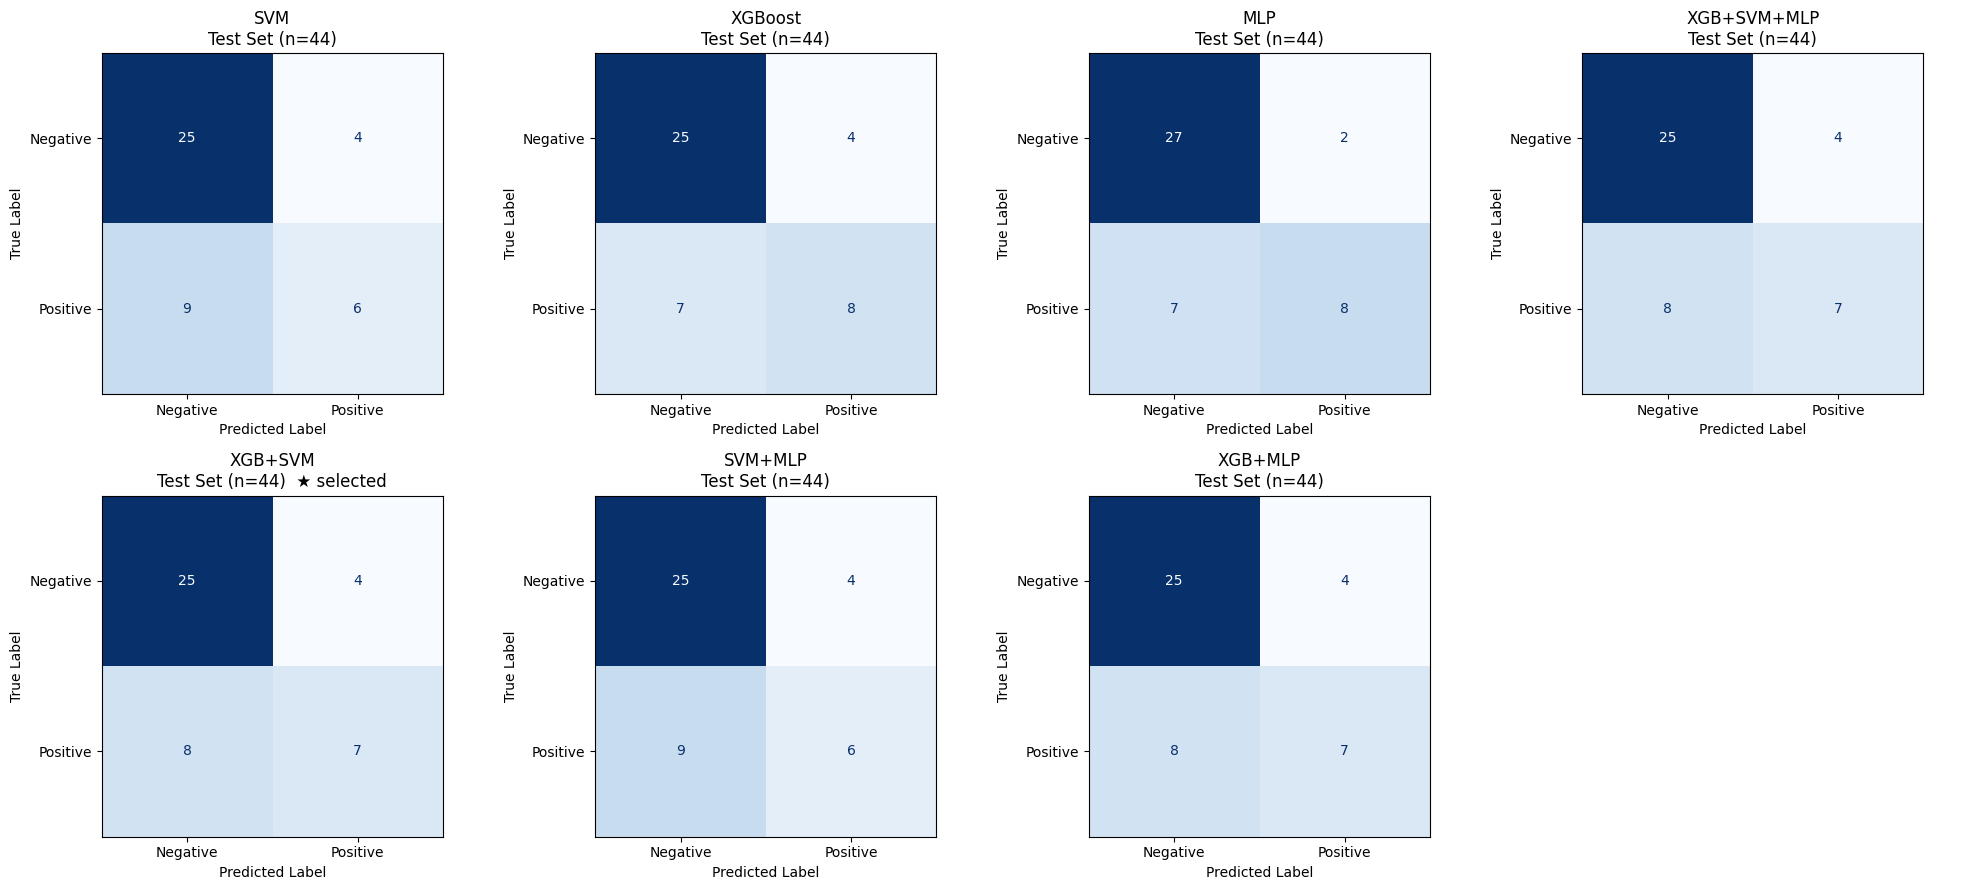


Confusion matrix values (test set):


,Model,TN,FP,FN,TP
0,SVM,25,4,9,6
1,XGBoost,25,4,7,8
2,MLP,27,2,7,8
3,XGB+SVM+MLP,25,4,8,7
4,XGB+SVM,25,4,8,7
5,SVM+MLP,25,4,9,6
6,XGB+MLP,25,4,8,7



✓ Test set confusion matrix visualization completed.
📁 Figure saved to: test_set_confusion_matrices.png


In [ ]:
# ============================================================
# TEST SET CONFUSION MATRICES — ALL 7 MODELS
# (same style as LOCO visualization, applied to test-set results)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 70)
print("TEST SET CONFUSION MATRICES")
print("=" * 70)


# ============================================================
# 1. VERIFY REQUIRED VARIABLES
# ============================================================

required_vars = ['model_probs', 'y_test_reset']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise NameError(
        "❌ Variabel berikut tidak ditemukan: "
        + ", ".join(missing_vars)
        + ". Jalankan cell Bootstrap CI + DeLong's Test terlebih dahulu."
    )

models = list(model_probs.keys())
print(f"\nModels found: {models}")


# ============================================================
# 2. CONFUSION MATRICES — ONE PER MODEL (TEST SET, n=44)
# ============================================================

print("\n")
print("=" * 70)
print("CONFUSION MATRICES — TEST SET (7 MODELS)")
print("=" * 70)

n_models = len(models)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows)
)

axes = axes.flatten()

for ax, model in zip(axes, models):

    prob = model_probs[model]
    pred = (prob >= 0.5).astype(int)

    cm = confusion_matrix(
        y_test_reset,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative', 'Positive']
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d'
    )

    title = f"{model}\nTest Set (n=44)"
    if model == selected_model_name:
        title += "  ★ selected"

    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# hide unused subplots if 7 models don't fill the grid
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig("test_set_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# 3. PRINT CONFUSION MATRIX VALUES
# ============================================================

print("\nConfusion matrix values (test set):")

cm_summary = []

for model in models:

    prob = model_probs[model]
    pred = (prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_reset,
        pred,
        labels=[0, 1]
    ).ravel()

    cm_summary.append({
        'Model': model,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

cm_summary_df = pd.DataFrame(cm_summary)

display(cm_summary_df)

print("\n✓ Test set confusion matrix visualization completed.")
print(f"📁 Figure saved to: test_set_confusion_matrices.png")

## ROC-AUC CURVE

TEST SET ROC CURVES

Models found: ['SVM', 'XGBoost', 'MLP', 'XGB+SVM+MLP', 'XGB+SVM', 'SVM+MLP', 'XGB+MLP']


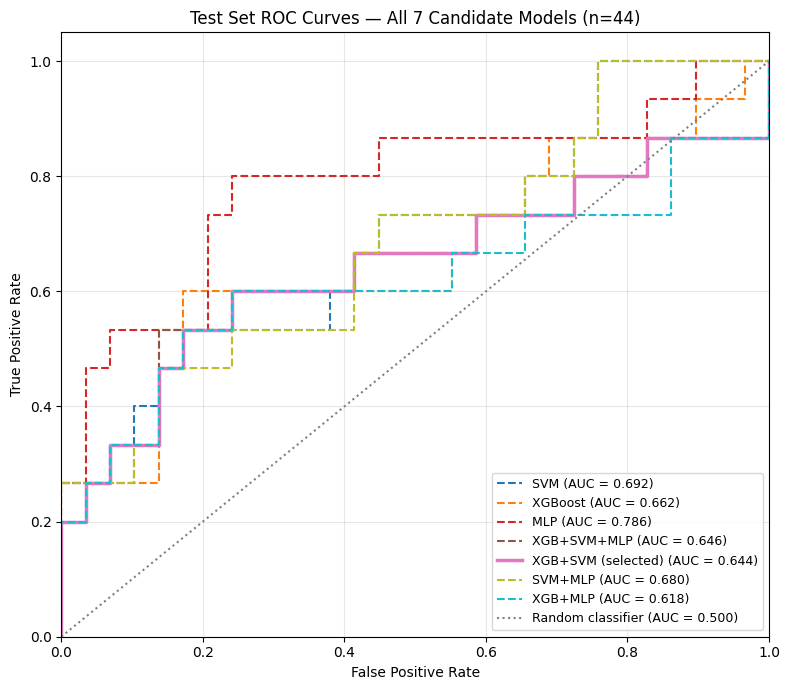


✓ Test set ROC curve visualization completed.
📁 Figure saved to: test_set_roc_curves.png


In [ ]:
# ============================================================
# TEST SET ROC CURVES — ALL 7 MODELS
# (same style as LOCO ROC curve visualization)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=" * 70)
print("TEST SET ROC CURVES")
print("=" * 70)


# ============================================================
# 1. VERIFY REQUIRED VARIABLES
# ============================================================

required_vars = ['model_probs', 'y_test_reset', 'selected_model_name']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise NameError(
        "❌ Variabel berikut tidak ditemukan: "
        + ", ".join(missing_vars)
        + ". Jalankan cell Bootstrap CI + DeLong's Test terlebih dahulu."
    )

models = list(model_probs.keys())
print(f"\nModels found: {models}")


# ============================================================
# 2. ROC CURVES — ALL 7 MODELS, TEST SET
# ============================================================

plt.figure(figsize=(8, 7))

# consistent color cycle so each model keeps the same color
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for model, color in zip(models, colors):

    y_true = y_test_reset
    y_proba = model_probs[model]

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc_value = auc(fpr, tpr)

    is_selected = (model == selected_model_name)

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5 if is_selected else 1.5,
        linestyle='-' if is_selected else '--',
        color=color,
        label=f"{model}{' (selected)' if is_selected else ''} (AUC = {roc_auc_value:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=':',
    linewidth=1.5,
    color='gray',
    label='Random classifier (AUC = 0.500)'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Test Set ROC Curves — All 7 Candidate Models (n=44)")

plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.tight_layout()
plt.savefig("test_set_roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Test set ROC curve visualization completed.")
print(f"📁 Figure saved to: test_set_roc_curves.png")

## 1️⃣4️⃣ SHAP Interpretability — Final Selected Model

Menjelaskan kontribusi tiap fitur terhadap prediksi model final (`selected_model_name`) menggunakan SHAP (memenuhi CLEAR item #43, opsional). Perlu `pip install shap --break-system-packages` bila belum tersedia di environment.

SHAP ANALYSIS — Selected model: XGB+SVM


PermutationExplainer explainer: 45it [00:29,  1.12it/s]


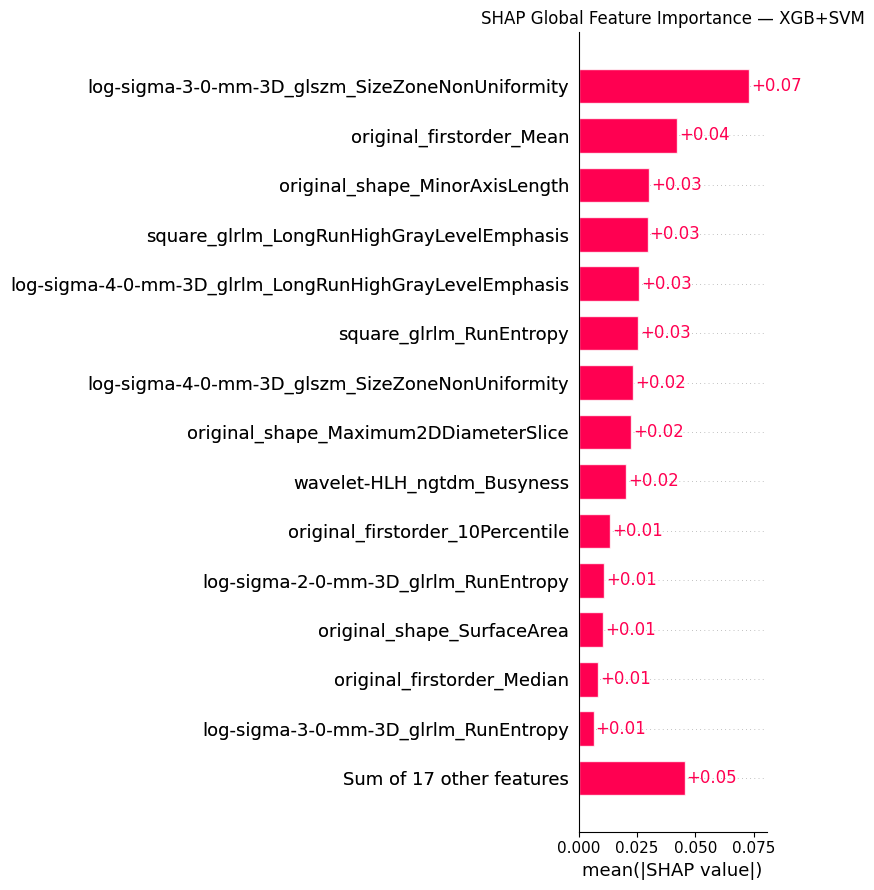

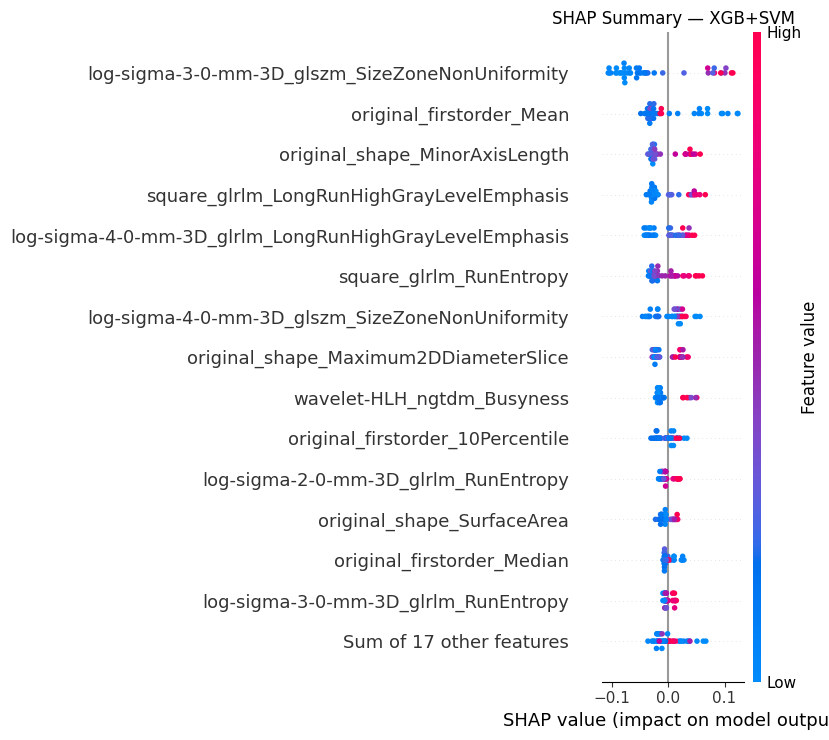


Top 15 features by mean |SHAP value|:
                                               Feature  Mean_Abs_SHAP
       log-sigma-3-0-mm-3D_glszm_SizeZoneNonUniformity       0.072960
                              original_firstorder_Mean       0.042031
                        original_shape_MinorAxisLength       0.029967
             square_glrlm_LongRunHighGrayLevelEmphasis       0.029462
log-sigma-4-0-mm-3D_glrlm_LongRunHighGrayLevelEmphasis       0.025813
                               square_glrlm_RunEntropy       0.025524
       log-sigma-4-0-mm-3D_glszm_SizeZoneNonUniformity       0.023372
                 original_shape_Maximum2DDiameterSlice       0.022266
                            wavelet-HLH_ngtdm_Busyness       0.020135
                      original_firstorder_10Percentile       0.013288
                  log-sigma-2-0-mm-3D_glrlm_RunEntropy       0.010912
                            original_shape_SurfaceArea       0.010350
                            original_firstorder_Med

In [ ]:
# ============================================================
# SHAP INTERPRETABILITY FOR THE FINAL SELECTED MODEL
# ============================================================
# !pip install -q shap --break-system-packages   # uncomment if not installed

import shap
import matplotlib.pyplot as plt

final_model_obj = final_models[selected_model_name]

print("=" * 80)
print(f"SHAP ANALYSIS — Selected model: {selected_model_name}")
print("=" * 80)

# Background sample for the explainer (keeps computation tractable)
background = shap.sample(X_train_sel, min(50, len(X_train_sel)), random_state=RANDOM_STATE)

# Universal wrapper: works for base learners, pipelines, and StackingClassifier alike
predict_fn = lambda x: final_model_obj.predict_proba(pd.DataFrame(x, columns=X_train_sel.columns))[:, 1]

explainer = shap.Explainer(predict_fn, background)
shap_values = explainer(X_test_sel)

# --- global feature importance (bar plot) ---
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title(f"SHAP Global Feature Importance — {selected_model_name}")
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300)
plt.show()

# --- beeswarm plot (distribution of feature effects) ---
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(f"SHAP Summary — {selected_model_name}")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300)
plt.show()

# --- top-15 features by mean |SHAP value| as a table ---
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': X_test_sel.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("\nTop 15 features by mean |SHAP value|:")
print(shap_importance_df.head(15).to_string(index=False))


## 1️⃣5️⃣ Final Model Export

Menyimpan model final (`selected_model_name`) — yang sudah di-fit di seluruh training set (171 pasien) — sebagai file `.joblib` untuk deployment/inference pada data baru (dipakai oleh bagian "Uji Model Final" di bawah).

In [ ]:
# ============================================================
# FINAL MODEL EXPORT
# ============================================================
# IMPORTANT:
# This exports the model already selected in Step 1 (Table A)
# and refit on the full training set in Step 2.
# It is NOT re-selected based on test-set performance.
# ============================================================

import joblib

final_model = final_models[selected_model_name]

save_path = "final_selected_model_pipeline.joblib"
joblib.dump(final_model, save_path)

print(f"Selected model (from LOCO comparison): {selected_model_name}")
print(f"📁 Model saved to: {save_path}")
print("✓ Fitted on the full TRAIN set (171 patients) only.")
print("✓ Held-out TEST data was not used for model selection.")


## 🚀 Uji Model Final dengan Data CSV Baru

Bagian ini akan memungkinkan Anda untuk mengunggah file CSV baru berisi *radiomics features* (tanpa label) dan menggunakan model `xgb_final_pipeline.joblib` yang telah dilatih untuk membuat prediksi.

**Penting:** Pastikan file CSV yang Anda unggah memiliki kolom fitur yang *sama* (walaupun mungkin urutannya berbeda atau ada kolom tambahan/kurang) seperti data yang digunakan untuk melatih model, karena model akan melakukan pra-pemrosesan yang sesuai.

Silakan unggah model `xgb_final_pipeline.joblib` yang telah Anda simpan sebelumnya.

In [ ]:
print('📂 Mengunggah file model xgb_final_pipeline.joblib...')

model_uploaded = files.upload()

# Identify uploaded file
model_filename = None

for filename in model_uploaded.keys():
    if 'joblib' in filename.lower():
        model_filename = filename
        print(f'✓ Model file teridentifikasi: {model_filename}')
        break

if not model_filename:
    print('❌ ERROR: File model .joblib tidak ditemukan!')
    raise FileNotFoundError('Please upload xgb_final_pipeline.joblib')

print(f'✓ File {model_filename} berhasil diunggah.')

📂 Mengunggah file model xgb_final_pipeline.joblib...


Saving xgb_final_pipeline (1).joblib to xgb_final_pipeline (1) (2).joblib
✓ Model file teridentifikasi: xgb_final_pipeline (1) (2).joblib
✓ File xgb_final_pipeline (1) (2).joblib berhasil diunggah.


In [ ]:
import pandas as pd
from google.colab import files
import joblib
import numpy as np

# Re-load the original dataset to get the definitive list of selected_features
# This ensures consistency with how the model was trained
print("🔄 Memuat ulang data pelatihan asli untuk mendapatkan daftar fitur yang benar...")
df_original = pd.read_csv(selected_features_file) # selected_features_file is from earlier in notebook
metadata_cols = ['PatientID', 'label'] # Assuming these are consistent
selected_features = [c for c in df_original.columns if c not in metadata_cols]
print(f"✓ {len(selected_features)} fitur teridentifikasi dari data pelatihan asli.")

print("\n📂 Silakan unggah file CSV baru berisi data untuk diuji (tanpa kolom 'label').")
print("   Pastikan file ini memiliki fitur-fitur yang sama seperti saat model dilatih.")

uploaded_test_data = files.upload()

# Asumsikan hanya satu file yang diunggah
new_test_filename = list(uploaded_test_data.keys())[0]
print(f"✓ File CSV untuk pengujian: {new_test_filename} berhasil diunggah.")

🔄 Memuat ulang data pelatihan asli untuk mendapatkan daftar fitur yang benar...
✓ 30 fitur teridentifikasi dari data pelatihan asli.

📂 Silakan unggah file CSV baru berisi data untuk diuji (tanpa kolom 'label').
   Pastikan file ini memiliki fitur-fitur yang sama seperti saat model dilatih.


Saving Test_data.csv to Test_data (2).csv
✓ File CSV untuk pengujian: Test_data (2).csv berhasil diunggah.


In [ ]:
print(f"\nLoading {new_test_filename}...")
df_new_test = pd.read_csv(new_test_filename, skipfooter=6, engine='python')
print(f"✓ Dataset baru dimuat. Shape: {df_new_test.shape}")

# Ensure 'PatientID' is not treated as a feature if it exists
# 'selected_features' is assumed to be defined from previous execution

# Identify features that are in selected_features but NOT in the new test dataframe
missing_features_in_new_data = [f for f in selected_features if f not in df_new_test.columns]

if missing_features_in_new_data:
    print(f"\n⚠️ Peringatan: Fitur berikut tidak ditemukan dalam file yang Anda unggah: {missing_features_in_new_data}")
    print("   Menambahkan fitur yang hilang dengan nilai NaN.")
    for feature in missing_features_in_new_data:
        df_new_test[feature] = np.nan

# Identify features that are in the new test dataframe but NOT in selected_features
extra_features_in_new_data = [f for f in df_new_test.columns if f not in selected_features and f != 'PatientID']
if extra_features_in_new_data:
    print(f"\n⚠️ Peringatan: Fitur berikut ada di file yang Anda unggah tetapi tidak ada di `selected_features` dan akan diabaikan: {extra_features_in_new_data}")

# Create X_new_test ensuring all selected_features are present and in the correct order
X_new_test = df_new_test[selected_features]

print(f"✓ Data uji siap dengan {X_new_test.shape[1]} fitur untuk diprediksi.")
display(X_new_test.head())


Loading Test_data (2).csv...
✓ Dataset baru dimuat. Shape: (6, 31)
✓ Data uji siap dengan 30 fitur untuk diprediksi.


,log-sigma-3-0-mm-3D_ngtdm_Coarseness,original_shape_MinorAxisLength,wavelet-LLL_gldm_GrayLevelNonUniformity,wavelet-LHH_glszm_ZoneVariance,original_firstorder_Skewness,original_firstorder_Kurtosis,log-sigma-4-0-mm-3D_ngtdm_Coarseness,log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformity,wavelet-LLL_firstorder_Mean,square_glszm_LargeAreaHighGrayLevelEmphasis,...,original_ngtdm_Coarseness,wavelet-HLH_glszm_GrayLevelNonUniformityNormalized,wavelet-HLH_glszm_LargeAreaLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,wavelet-LHL_ngtdm_Contrast,original_firstorder_Mean,wavelet-LLL_firstorder_Skewness,square_glrlm_RunEntropy,log-sigma-4-0-mm-3D_firstorder_10Percentile,wavelet-LLL_firstorder_Median
0,0.019659,8.501208,41.397112,4.840000e+02,0.755771,3.238591,0.017268,2.333333,198.805246,7.835292e+03,...,0.017376,0.680000,2.057630e+04,74.445339,0.032674,69.459512,0.721126,3.456194,3.123942,175.350841
1,0.000774,31.056696,1906.398336,2.158532e+07,1.454440,4.463807,0.000852,22.238095,42.652683,1.398352e+06,...,0.000608,0.333333,3.909214e+06,1571.948469,0.005722,14.891275,1.396955,4.320735,-3.832006,-19.880112
2,0.024716,10.863610,11.185535,2.308133e+04,-0.037291,2.426432,0.030700,5.473684,1732.785593,5.237551e+03,...,0.023890,0.520000,2.752565e+04,26.892214,0.060849,611.119067,-0.082905,5.068607,-62.253679,1720.275881
3,0.000574,57.786247,1743.809707,2.569733e+07,1.365079,6.620477,0.000617,46.897959,672.164790,1.858732e+06,...,0.000444,0.548828,1.641908e+07,2768.692519,0.011334,237.457365,1.396380,4.716466,-19.917605,639.439291
4,0.000165,57.944938,9307.333670,2.593609e+08,1.358182,5.900442,0.000187,35.400000,76.235052,3.317062e+07,...,0.000126,0.612188,1.673522e+08,8454.767289,0.003519,26.912170,1.385905,4.920570,-12.242078,55.000673


In [ ]:
print(f"\n🔄 Memuat model `{model_filename}`...")
model_for_inference = joblib.load(model_filename)
print("✓ Model berhasil dimuat!")

print("\n🔄 Melakukan prediksi pada data baru...")

# Prediksi label dan probabilitas
predictions = model_for_inference.predict(X_new_test)
probabilities = model_for_inference.predict_proba(X_new_test)[:, 1] # Probabilitas kelas 1

# Tambahkan hasil prediksi ke DataFrame asli untuk kemudahan analisis
df_new_test['Predicted_Label'] = predictions
df_new_test['Probability_Class_1'] = probabilities

print("✓ Prediksi selesai!")
print("\n=======================================================")
print("✅ Hasil Prediksi:")
print("=======================================================")
# Display using selected_features for consistency
display(df_new_test[['PatientID'] + selected_features[:8] + ['Predicted_Label', 'Probability_Class_1']].head())

print("\nDistribusi prediksi label:")
print(df_new_test['Predicted_Label'].value_counts())


🔄 Memuat model `xgb_final_pipeline (1) (2).joblib`...
✓ Model berhasil dimuat!

🔄 Melakukan prediksi pada data baru...
✓ Prediksi selesai!

✅ Hasil Prediksi:


,PatientID,log-sigma-3-0-mm-3D_ngtdm_Coarseness,original_shape_MinorAxisLength,wavelet-LLL_gldm_GrayLevelNonUniformity,wavelet-LHH_glszm_ZoneVariance,original_firstorder_Skewness,original_firstorder_Kurtosis,log-sigma-4-0-mm-3D_ngtdm_Coarseness,log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformity,Predicted_Label,Probability_Class_1
0,Center1_087,0.019659,8.501208,41.397112,4.840000e+02,0.755771,3.238591,0.017268,2.333333,1,0.570566
1,Center2_41,0.000774,31.056696,1906.398336,2.158532e+07,1.454440,4.463807,0.000852,22.238095,1,0.835616
2,Center3_11,0.024716,10.863610,11.185535,2.308133e+04,-0.037291,2.426432,0.030700,5.473684,0,0.127113
3,Center3_13,0.000574,57.786247,1743.809707,2.569733e+07,1.365079,6.620477,0.000617,46.897959,1,0.902122
4,Center4_26,0.000165,57.944938,9307.333670,2.593609e+08,1.358182,5.900442,0.000187,35.400000,1,0.985046



Distribusi prediksi label:
Predicted_Label
1    4
0    2
Name: count, dtype: int64


## 📈 Hasil Prediksi Lengkap dengan Confidence Level

In [ ]:
print("Menampilkan semua data dengan prediksi label dan confidence level:")
display(df_new_test[['PatientID', 'Predicted_Label', 'Probability_Class_1']])

print("\nUntuk melihat semua fitur beserta hasil prediksi:")
display(df_new_test)

Menampilkan semua data dengan prediksi label dan confidence level:


,PatientID,Predicted_Label,Probability_Class_1
0,Center1_087,1,0.570566
1,Center2_41,1,0.835616
2,Center3_11,0,0.127113
3,Center3_13,1,0.902122
4,Center4_26,1,0.985046
5,Center4_31,0,0.361470



Untuk melihat semua fitur beserta hasil prediksi:


,PatientID,log-sigma-3-0-mm-3D_ngtdm_Coarseness,original_shape_MinorAxisLength,wavelet-LLL_gldm_GrayLevelNonUniformity,wavelet-LHH_glszm_ZoneVariance,original_firstorder_Skewness,original_firstorder_Kurtosis,log-sigma-4-0-mm-3D_ngtdm_Coarseness,log-sigma-2-0-mm-3D_glszm_GrayLevelNonUniformity,wavelet-LLL_firstorder_Mean,...,wavelet-HLH_glszm_LargeAreaLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,wavelet-LHL_ngtdm_Contrast,original_firstorder_Mean,wavelet-LLL_firstorder_Skewness,square_glrlm_RunEntropy,log-sigma-4-0-mm-3D_firstorder_10Percentile,wavelet-LLL_firstorder_Median,Predicted_Label,Probability_Class_1
0,Center1_087,0.019659,8.501208,41.397112,4.840000e+02,0.755771,3.238591,0.017268,2.333333,198.805246,...,2.057630e+04,74.445339,0.032674,69.459512,0.721126,3.456194,3.123942,175.350841,1,0.570566
1,Center2_41,0.000774,31.056696,1906.398336,2.158532e+07,1.454440,4.463807,0.000852,22.238095,42.652683,...,3.909214e+06,1571.948469,0.005722,14.891275,1.396955,4.320735,-3.832006,-19.880112,1,0.835616
2,Center3_11,0.024716,10.863610,11.185535,2.308133e+04,-0.037291,2.426432,0.030700,5.473684,1732.785593,...,2.752565e+04,26.892214,0.060849,611.119067,-0.082905,5.068607,-62.253679,1720.275881,0,0.127113
3,Center3_13,0.000574,57.786247,1743.809707,2.569733e+07,1.365079,6.620477,0.000617,46.897959,672.164790,...,1.641908e+07,2768.692519,0.011334,237.457365,1.396380,4.716466,-19.917605,639.439291,1,0.902122
4,Center4_26,0.000165,57.944938,9307.333670,2.593609e+08,1.358182,5.900442,0.000187,35.400000,76.235052,...,1.673522e+08,8454.767289,0.003519,26.912170,1.385905,4.920570,-12.242078,55.000673,1,0.985046
5,Center4_31,0.003529,15.811760,319.058387,9.054836e+05,0.856411,4.328499,0.003983,10.243243,72.327188,...,1.705563e+06,479.187074,0.017101,25.318928,0.814313,3.955883,-23.404966,58.790330,0,0.361470
